In [73]:
!pip install fvcore

In [74]:
import warnings
import time
import os
import platform
import psutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import cpuinfo

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, cohen_kappa_score, classification_report, confusion_matrix
from fvcore.nn import FlopCountAnalysis

# Doctor's Handwriting Recognition: Comparative Model Analysis

This report details the performance and efficiency of ten distinct deep learning architectures for classifying handwritten medical prescriptions. The analysis specifically includes: **Classic & Modern CNNs** (e.g., **VGG16, ResNet50, DenseNet121, EfficientNetV2-S**), **Pure Transformers** (**ViT-B/16**), and **Hierarchical/Hybrid Models** (**Swin-T, MaxViT**).

The study focuses on three core areas:
- **Accuracy** (Test, F1-Score, AUC)
- **Computational Cost** (FLOPs, Parameters)
- And a derived **Practicality Score** to identify the most robust and deployable model for resource-constrained environments.

# Configurations

In [75]:
# --- Suppress specific warnings from torchvision ---
warnings.filterwarnings("ignore", message="The parameter 'pretrained' is deprecated.*")
warnings.filterwarnings("ignore", message="The parameter 'weights' is deprecated.*")

In [76]:
FINAL_RESULTS_TABLE = {}

CONFIG = {
    "train_dir": '/kaggle/input/doctors-handwritten-prescription-dataset/dataset/TRAIN',
    "test_dir": '/kaggle/input/doctors-handwritten-prescription-dataset/dataset/TEST',
    "base_model_path": '/kaggle/input/dr.-handwriting-recognizing-models-weights/pytorch/variant-01/1/',
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size": 32,
    "num_workers": min(4, os.cpu_count()),
    "image_size": 224
}

In [77]:
def generate_system_report_md():
    """
    Gathers and formats a detailed report of the system's hardware
    and environment as a Markdown table.
    """
    
    # --- Start building the Markdown string ---
    md_string = "# 🚀 System Hardware & Environment Report\n\n"
    md_string += "| Category              | Specification                                  |\n"
    md_string += "| :-------------------- | :--------------------------------------------- |\n"
    
    # --- OS Information ---
    uname = platform.uname()
    md_string += f"| **OS** | {uname.system} {uname.release} |\n"
    md_string += f"| **Architecture** | {uname.machine} |\n"
    
    # --- CPU Information ---
    cpu_info = cpuinfo.get_cpu_info()
    md_string += f"| **Processor** | {cpu_info['brand_raw']} |\n"
    md_string += f"| **Physical Cores** | {psutil.cpu_count(logical=False)} |\n"
    md_string += f"| **Total Cores** | {psutil.cpu_count(logical=True)} |\n"

    # --- RAM Information ---
    svmem = psutil.virtual_memory()
    md_string += f"| **Total RAM** | {svmem.total / (1024**3):.2f} GB |\n"

    # --- GPU Information ---
    if torch.cuda.is_available():
        gpu_count = torch.cuda.device_count()
        md_string += f"| **CUDA Available** | Yes |\n"
        for i in range(gpu_count):
            gpu_name = torch.cuda.get_device_name(i)
            total_mem = torch.cuda.get_device_properties(i).total_memory / (1024**3)
            md_string += f"| **GPU {i} Model** | {gpu_name} |\n"
            md_string += f"| **GPU {i} VRAM** | {total_mem:.2f} GB |\n"
    else:
        md_string += f"| **CUDA Available** | No |\n"
        
    return md_string

display(Markdown(generate_system_report_md()))

# 🚀 System Hardware & Environment Report

| Category              | Specification                                  |
| :-------------------- | :--------------------------------------------- |
| **OS** | Linux 6.6.56+ |
| **Architecture** | x86_64 |
| **Processor** | Intel(R) Xeon(R) CPU @ 2.00GHz |
| **Physical Cores** | 2 |
| **Total Cores** | 4 |
| **Total RAM** | 31.35 GB |
| **CUDA Available** | Yes |
| **GPU 0 Model** | Tesla P100-PCIE-16GB |
| **GPU 0 VRAM** | 15.89 GB |


---

# Project Evaluation Metrics

To conduct a comprehensive comparison of the deep learning models, we evaluated them across two main categories: **Performance** and **Efficiency**. A final **Practicality Score** was then calculated to determine the best overall model for the project's specific real-world goals.

## 📈 Performance Metrics

These metrics quantify the predictive power and reliability of each model on the unseen test set.

| Metric | What it Measures | Why it's Important |
| :--- | :--- | :--- |
| **Test Accuracy** | The overall percentage of correct predictions. | Provides the most direct and intuitive measure of the model's overall success. |
| **F1-Score (Macro)** | The balanced average of Precision and Recall across all classes. | A robust metric that accounts for both false positives and false negatives, treating every class as equally important. |
| **AUC Score (Macro)** | The Area Under the ROC Curve, averaged for all classes. | Measures the model's ability to distinguish between classes. A score near 1.0 indicates excellent class separation. |
| **Cohen's Kappa** | The agreement between predictions and true labels, corrected for chance. | Validates that the model's accuracy is statistically significant and not just a result of a skewed dataset. |

## ⏱️ Efficiency Metrics

These metrics quantify the computational cost and resource requirements for deploying and running each model, which is critical for practical applications.

| Metric | What it Measures | Why it's Important |
| :--- | :--- | :--- |
| **Inference Time (ms/CPU)** | The average time to make a prediction on a single image using a CPU. | Directly measures the user-facing speed (latency). Lower is better for a responsive application. |
| **GFLOPs** | Billions of floating-point operations needed to process one image. | A hardware-independent measure of the model's computational complexity. Lower is more energy-efficient. |
| **Params (M)** | The total number of trainable weights in the model (in millions). | Measures the model's architectural size, which correlates with file size and memory footprint. |
| **Peak Memory (MB)** | The maximum RAM or VRAM the model consumes during a prediction. | Defines the minimum hardware requirement. A low value is essential for deployment on low-cost devices. |
<br/>


## 📈 Practicality Score: The Final Model Benchmark

The Practicality Score is a **composite metric (0–10)** designed to find the most balanced and deployable model for resource-constrained environments. It directly answers the question: *"Which model offers the best trade-off between predictive power and real-world efficiency?"*

A model only achieves a score of **10** if it is the best performer across *all* categories.


### How It Is Calculated

The score is calculated in three main steps:

1.  **Normalization (0-1 Scale, where 1 is Best):** All metrics are scaled to a common range. Two different methods are used:
    * **Performance (Ratio-to-Best):** Accuracy, Kappa, and AUC are scaled relative to the top performer.
        $$\text{Score} = \frac{\text{Model's Value}}{\text{Best Model's Score}}$$
    * **Efficiency (Min-Max Scaling):** Inference Time and Peak Memory are scaled across the full range of performers, from worst to best. This method gives the best performer a score of 1 and the worst a score of 0.
        $$\text{Score} = 1 - \frac{\text{Model's Value} - \text{Best Value}}{\text{Worst Value} - \text{Best Value}}$$

2.  **Weighting:** The normalized scores are combined using a weighted average that reflects the project's priorities.

3.  **Final Score:** The result is scaled by 10.


### The Weighting Rationale (Defining "Practical")

The weights define the balance between pure performance and real-world utility, with a 50/50 split between the two categories.

| Category | Metric | Weight | Rationale |
| :--- | :--- | :--- | :--- |
| **Performance (50%)**| Test Accuracy | **0.6** | The primary measure of correctness. |
| | Kappa & AUC | **0.2 each**| Supporting metrics for robustness and class separation ability. |
| **Efficiency (50%)** | Inference Time | **0.5** | Speed is critical for user experience. |
| | Peak Memory | **0.5** | Memory is a hard hardware constraint for deployment. |


### Mathematical Formula

The final score is derived from the normalized (norm) scores.

First, the **Performance Score** ($\text{P}_{\text{score}}$) is calculated:
$$\text{P}_{\text{score}} = 0.6 \cdot \frac{\text{Acc}}{\text{Acc}_{\text{best}}} + 0.2 \cdot \frac{\text{Kappa}}{\text{Kappa}_{\text{best}}} + 0.2 \cdot \frac{\text{AUC}}{\text{AUC}_{\text{best}}}$$

Next, the **Efficiency Score** ($\text{E}_{\text{score}}$) is calculated using the normalized time and memory scores:
$$\text{Time}_{\text{norm}} = 1 - \frac{\text{Time} - \text{Time}_{\text{min}}}{\text{Time}_{\text{max}} - \text{Time}_{\text{min}}}$$
$$\text{Mem}_{\text{norm}} = 1 - \frac{\text{Mem} - \text{Mem}_{\text{min}}}{\text{Mem}_{\text{max}} - \text{Mem}_{\text{min}}}$$
$$\text{E}_{\text{score}} = 0.5 \cdot \text{Time}_{\text{norm}} + 0.5 \cdot \text{Mem}_{\text{norm}}$$

Finally, the two scores are combined to get the **Practicality Score**:
$$\text{Practicality Score} = 10 \times \left( 0.5 \cdot \text{P}_{\text{score}} + 0.5 \cdot \text{E}_{\text{score}} \right)$$

In [78]:
def evaluate_and_benchmark(model, model_name, image_size, dataloader, class_names, device):
    """
    Runs a full evaluation and benchmark on a single model, returning its metrics.
    
    This updated version visualizes the classification report and confusion matrix
    and removes redundant text-based outputs.
    """
    print(f"\n\n--- Evaluating and Benchmarking: {model_name.upper()} ---")
    
    # --- Part 1: Performance Evaluation ---
    model.to(device)
    model.eval()
    y_true, y_scores = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc=f"Testing {model_name}"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(F.softmax(outputs, dim=1).cpu().numpy())

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    y_pred = np.argmax(y_scores, axis=1)

    # --- Part 2: Efficiency Benchmarking ---
    peak_memory_mb = 0
    if device == 'cuda':
        dummy_input_gpu = torch.randn(1, 3, image_size, image_size, device=device)
        torch.cuda.reset_peak_memory_stats(device)
        with torch.no_grad(): _ = model(dummy_input_gpu)
        peak_memory_mb = torch.cuda.max_memory_allocated(device) / (1024 * 1024)

    model_cpu = model.to('cpu').eval()
    dummy_input_cpu = torch.randn(1, 3, image_size, image_size)
    
    if device == 'cpu':
        process = psutil.Process(os.getpid())
        peak_memory_mb = process.memory_info().rss / (1024 * 1024)

    with torch.no_grad():
        for _ in range(20): _ = model_cpu(dummy_input_cpu) # Warmup
        timings = []
        for _ in range(100):
            start_time = time.time(); _ = model_cpu(dummy_input_cpu); end_time = time.time()
            timings.append((end_time - start_time) * 1000)

    # --- Part 3: Compile Metrics ---
    performance_metrics = {}
    try:
        performance_metrics = {
            "Test Accuracy": accuracy_score(y_true, y_pred),
            "F1 (Macro)": f1_score(y_true, y_pred, average='macro', zero_division=0),
            "AUC": roc_auc_score(y_true, y_scores, multi_class="ovr", average="macro"),
            "Kappa": cohen_kappa_score(y_true, y_pred)
        }
    except Exception as e:
        print(f"Could not calculate performance metrics for {model_name}. Error: {e}")

    efficiency_metrics = {
        "Params (M)": sum(p.numel() for p in model_cpu.parameters()) / 1e6,
        "GFLOPs": FlopCountAnalysis(model_cpu, dummy_input_cpu).total() / 1e9,
        "Inference Time (ms/CPU)": np.mean(timings),
        "Peak Memory (MB)": peak_memory_mb
    }
    
    final_metrics = {**performance_metrics, **efficiency_metrics}
    
    # --- Part 4: Print and Visualize Detailed Report ---
    print(f"--- Finished: {model_name.upper()} ---")
    for name, value in final_metrics.items():
        print(f"{name:<25}: {value:.4f}")
    
    try:
        report_dict = classification_report(y_true, y_pred, target_names=class_names, zero_division=0, output_dict=True)
        # Exclude summary rows for a cleaner plot
        report_df = pd.DataFrame(report_dict).iloc[:-1, :].T  
        
        plt.figure(figsize=(10, max(2, len(class_names) // 4)))
        sns.heatmap(report_df[['precision', 'recall', 'f1-score']], annot=True, cmap='viridis', fmt='.2f')
        plt.title(f'Classification Report for {model_name}')
        plt.show()
    except Exception as e:
        print(f"\nCould not plot classification report: {e}")

    try:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(max(8, len(class_names) // 5), max(6, len(class_names) // 5))) # Adjust size
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.title(f'Confusion Matrix for {model_name}')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()
    except Exception as e:
        print(f"\nCould not plot confusion matrix: {e}")

    print("-" * 50 + "\n")
    
    return final_metrics

In [79]:
def calculate_practicality_score(results_df):
    weights = {'performance': {'Test Accuracy': 0.6, 'Kappa': 0.2, 'AUC': 0.2},
               'efficiency': {'Inference Time (ms/CPU)': 0.5, 'Peak Memory (MB)': 0.5}}
    category_weights = {'performance': 0.5, 'efficiency': 0.5}
    df = results_df.copy()

    df['acc_norm'] = df['Test Accuracy'] / df['Test Accuracy'].max()
    df['kappa_norm'] = df['Kappa'] / df['Kappa'].max()
    df['auc_norm'] = df['AUC'] / df['AUC'].max()

    def min_max_scaler(series):
        if series.max() == series.min(): return pd.Series(1.0, index=series.index)
        return 1 - ((series - series.min()) / (series.max() - series.min()))

    df['time_norm'] = min_max_scaler(df['Inference Time (ms/CPU)'])
    df['mem_norm'] = min_max_scaler(df['Peak Memory (MB)'])

    df['performance_score'] = (df['acc_norm']*weights['performance']['Test Accuracy'] + 
                               df['kappa_norm']*weights['performance']['Kappa'] + 
                               df['auc_norm']*weights['performance']['AUC'])
    df['efficiency_score'] = (df['time_norm']*weights['efficiency']['Inference Time (ms/CPU)'] + 
                              df['mem_norm']*weights['efficiency']['Peak Memory (MB)'])
    
    df['Practicality Score'] = (df['performance_score']*category_weights['performance'] + 
                                df['efficiency_score']*category_weights['efficiency']) * 10
    
    return df.drop(columns=[col for col in df.columns if '_norm' in col or '_score' in col])

---

# Helper Functions

In [81]:
def get_dataloaders(train_dir, test_dir, image_size, batch_size, num_workers):
    """
    Creates and returns the test dataloader and the list of class names.
    The train_dir is only used to ensure the class-to-index mapping is correct.
    """
    data_transforms = {
        'train': transforms.Compose([transforms.Resize((image_size, image_size)), transforms.ToTensor()]),
        'test': transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
    }
    # We need the train dataset folder structure to get the correct class names
    train_dataset = datasets.ImageFolder(train_dir, data_transforms["train"])
    test_dataset = datasets.ImageFolder(test_dir, data_transforms["test"])
    
    # Ensure test set uses the same class mapping as the training set
    test_dataset.class_to_idx = train_dataset.class_to_idx
    
    dataloaders = {
        'test': DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    }
    class_names = train_dataset.classes
    return dataloaders, class_names

In [88]:
def plot_leaderboard(results_df):
    """
    Creates a leaderboard-style bar chart of the Practicality Score.
    """
    df_sorted = results_df.sort_values(by='Practicality Score', ascending=False)
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 8))

    palette = sns.color_palette("RdYlGn", n_colors=len(df_sorted))
    bars = ax.barh(df_sorted.index, df_sorted['Practicality Score'], color=palette)

    for i, bar in enumerate(bars):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                f'#{i+1}', va='center', ha='left', fontsize=12, fontweight='bold')

    ax.set_xlabel('Practicality Score (0-10)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Model Architecture', fontsize=12, fontweight='bold')
    ax.set_title('Model Performance Leaderboard', fontsize=16, fontweight='bold', pad=20)
    
    ax.invert_yaxis()
    ax.set_xlim(0, 11)
    sns.despine(left=True, bottom=True)
    
    plt.tight_layout()
    plt.show()

In [94]:
def generate_final_report(results_dict):
    """
    Takes the dictionary of all model results, calculates the practicality score,
    displays the final table, and plots the leaderboard chart.
    """
    if not results_dict:
        print("Results dictionary is empty. Nothing to report.")
        return

    final_df = pd.DataFrame(results_dict).T
    final_df_with_score = calculate_practicality_score(final_df)
    
    print("\n\n--- FINAL COMPARISON TABLE (Sorted by Practicality Score) ---")
    display(final_df_with_score.sort_values(by='Practicality Score', ascending=False).style.format("{:.4f}"))
    
    plot_leaderboard(final_df_with_score)

---

# Environment Setup

In [82]:
print(f"Using device: {CONFIG['device']}")

dataloaders, class_names = get_dataloaders(
    CONFIG["train_dir"], CONFIG["test_dir"], CONFIG["image_size"], CONFIG["batch_size"], CONFIG["num_workers"])
num_classes = len(class_names)
print(f"Found {num_classes} classes.")
print(f"Default dataloader created with image size {CONFIG['image_size']}x{CONFIG['image_size']}.")

Using device: cuda
Found 78 classes.
Default dataloader created with image size 224x224.


---

# Final Evaluation

In [83]:
def get_model_architectures(num_classes):
    return {
        "VGG16": lambda: (
            model := models.vgg16(weights=None),
            setattr(model, 'classifier', nn.Sequential(
                nn.Linear(model.classifier[0].in_features, 512),
                nn.ReLU(), nn.Dropout(0.5), nn.Linear(512, num_classes)
            )), model
        )[-1],

        "ResNet50": lambda: (
            model := models.resnet50(weights=None),
            setattr(model, 'fc', nn.Linear(model.fc.in_features, num_classes)), model
        )[-1],

        "DenseNet121": lambda: (
            model := models.densenet121(weights=None),
            setattr(model, 'classifier', nn.Linear(model.classifier.in_features, num_classes)), model
        )[-1],

        "EfficientNet-V2-S": lambda: (
            model := models.efficientnet_v2_s(weights=None),
            setattr(model.classifier, '1', nn.Linear(model.classifier[1].in_features, num_classes)), model
        )[-1],

        "ViT-B/16": lambda: (
            model := models.vit_b_16(weights=None, image_size=CONFIG['image_size']),
            setattr(model.heads, 'head', nn.Linear(model.heads.head.in_features, num_classes)), model
        )[-1],

        "Swin-T": lambda: (
            model := models.swin_t(weights=None),
            setattr(model, 'head', nn.Linear(model.head.in_features, num_classes)), model
        )[-1],

        "MaxViT-T": lambda: (
            model := models.maxvit_t(weights=None),
            setattr(model.classifier, '5', nn.Linear(model.classifier[5].in_features, num_classes)), model
        )[-1],
        
        "ConvNeXt-Tiny": lambda: (
            model := models.convnext_tiny(weights=None),
            setattr(model.classifier, '2', nn.Linear(model.classifier[2].in_features, num_classes)), model
        )[-1],
        
        "MobileNet-V3-Large": lambda: (
            model := models.mobilenet_v3_large(weights=None),
            setattr(model.classifier, '3', nn.Linear(model.classifier[3].in_features, num_classes)), model
        )[-1],
        
        "RegNet-Y-16GF": lambda: (
            model := models.regnet_y_16gf(weights=None),
            setattr(model, 'fc', nn.Linear(model.fc.in_features, num_classes)), model
        )[-1]
    }

Evaluating All Models:   0%|          | 0/10 [00:00<?, ?it/s]



--- Evaluating and Benchmarking: VGG16 ---


Testing VGG16:   0%|          | 0/30 [00:00<?, ?it/s]

--- Finished: VGG16 ---
Test Accuracy            : 0.8504
F1 (Macro)               : 0.8425
AUC                      : 0.9904
Kappa                    : 0.8485
Params (M)               : 27.6003
GFLOPs                   : 15.3595
Inference Time (ms/CPU)  : 182.1680
Peak Memory (MB)         : 482.6436


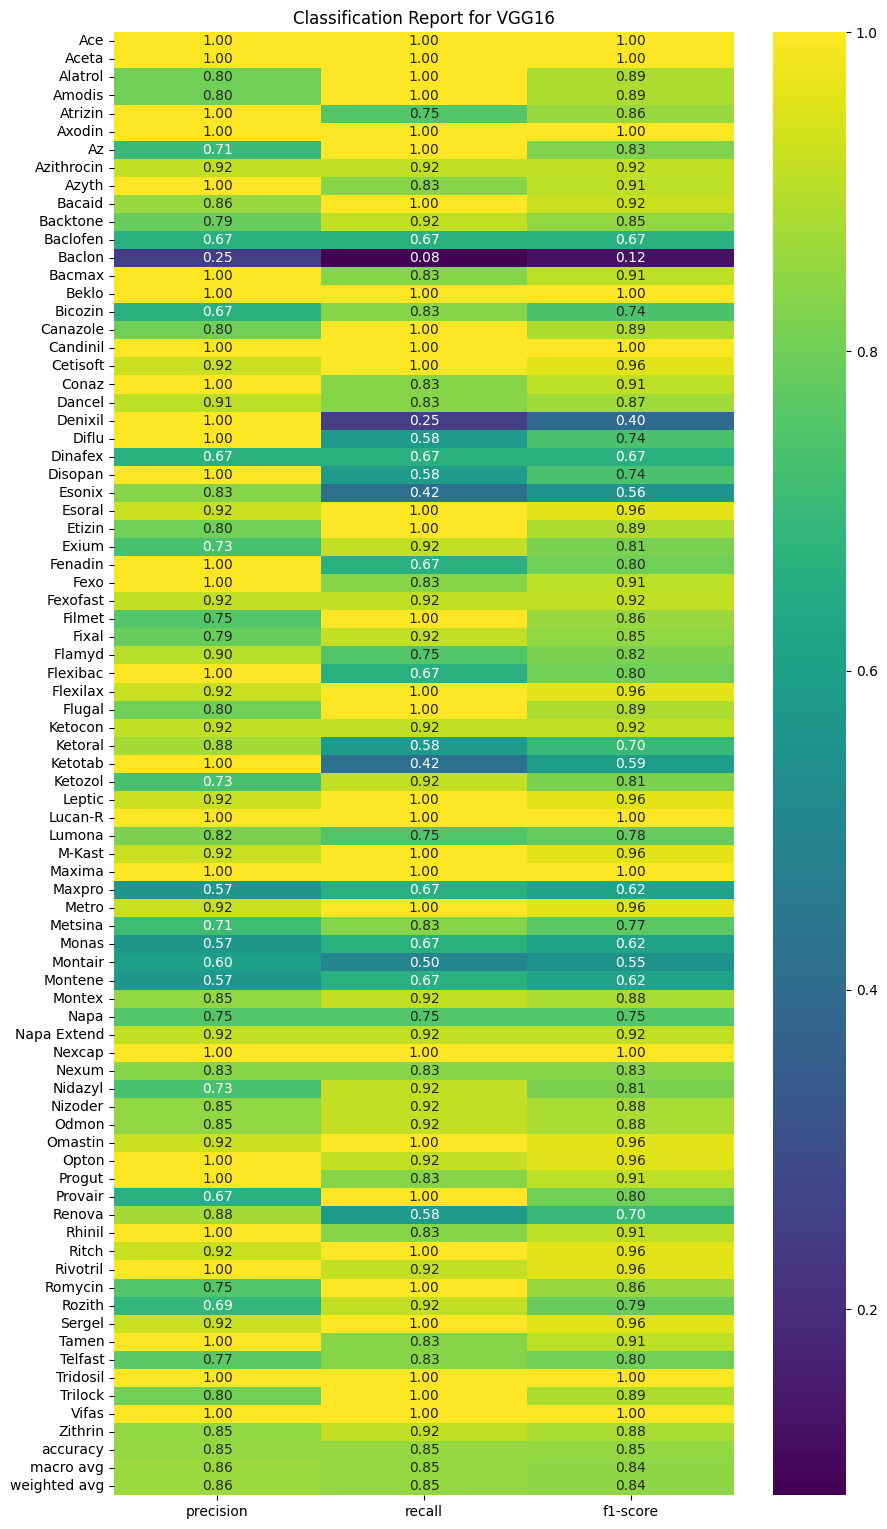

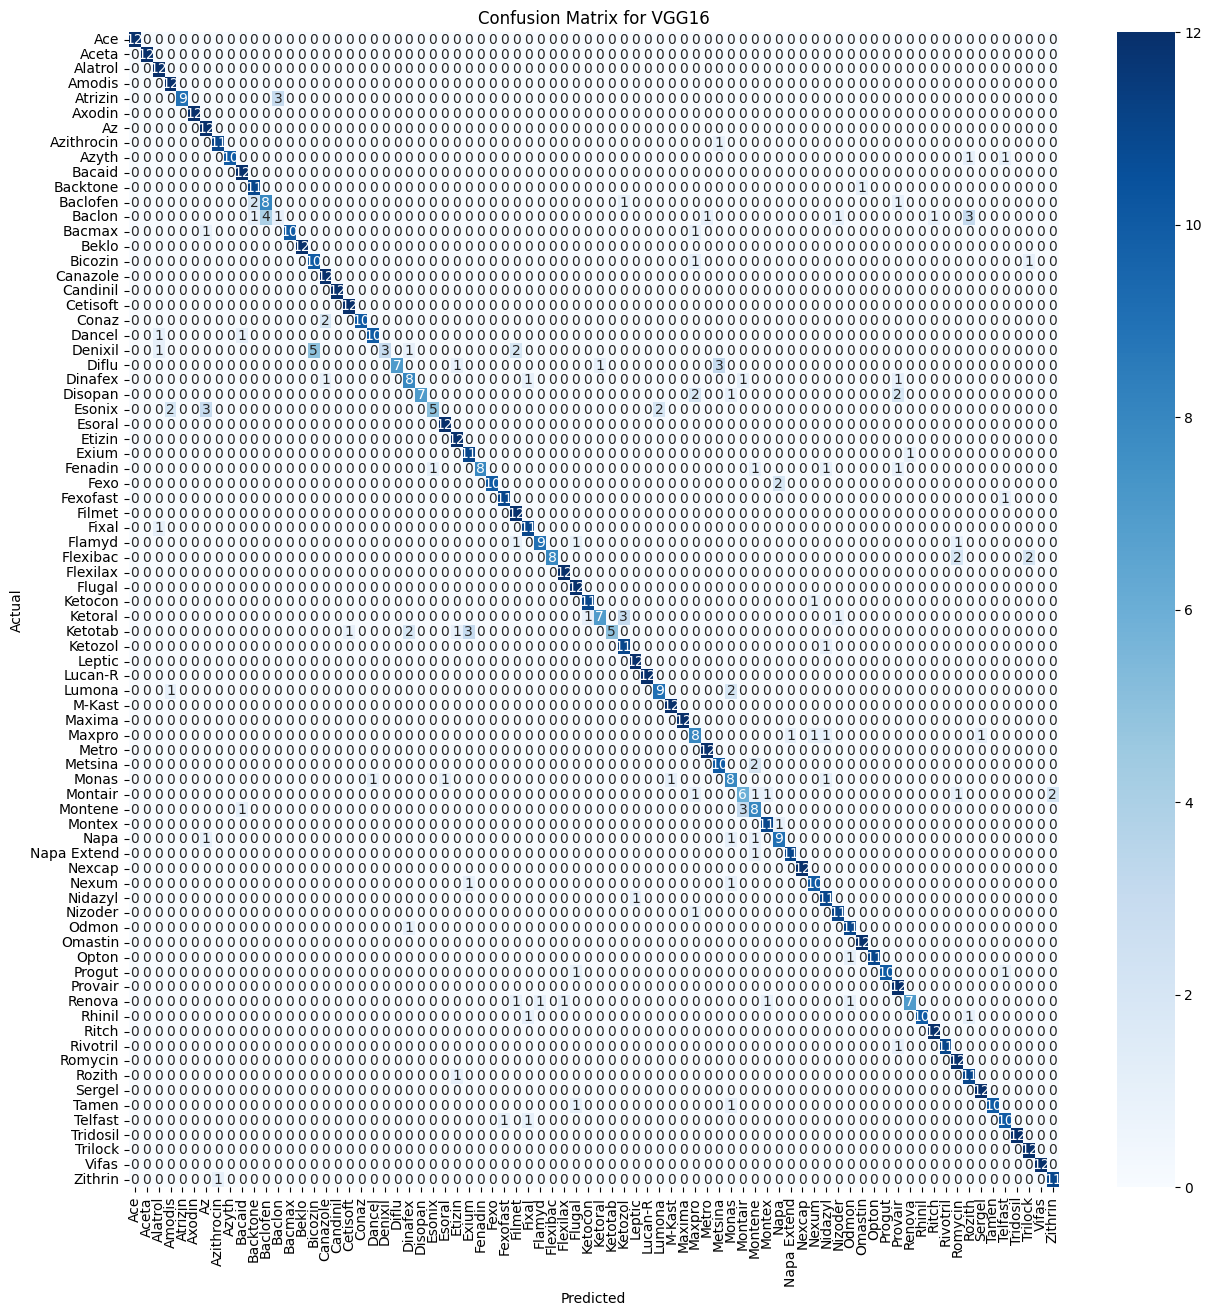

--------------------------------------------------



--- Evaluating and Benchmarking: RESNET50 ---


Testing ResNet50:   0%|          | 0/30 [00:00<?, ?it/s]

--- Finished: RESNET50 ---
Test Accuracy            : 0.8291
F1 (Macro)               : 0.8228
AUC                      : 0.9910
Kappa                    : 0.8268
Params (M)               : 23.6679
GFLOPs                   : 4.1096
Inference Time (ms/CPU)  : 75.5014
Peak Memory (MB)         : 136.8926


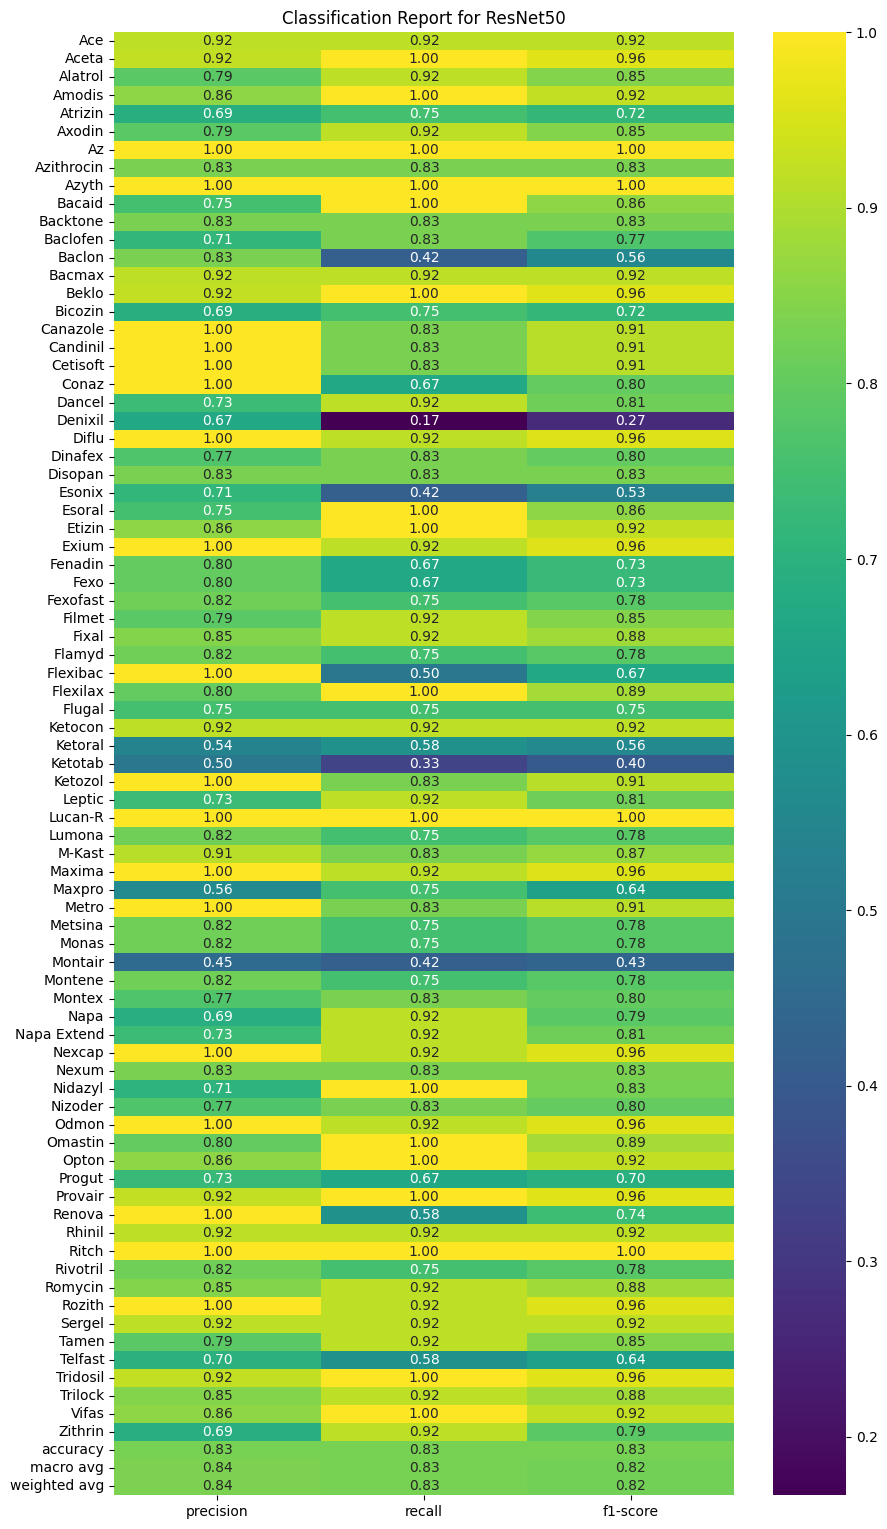

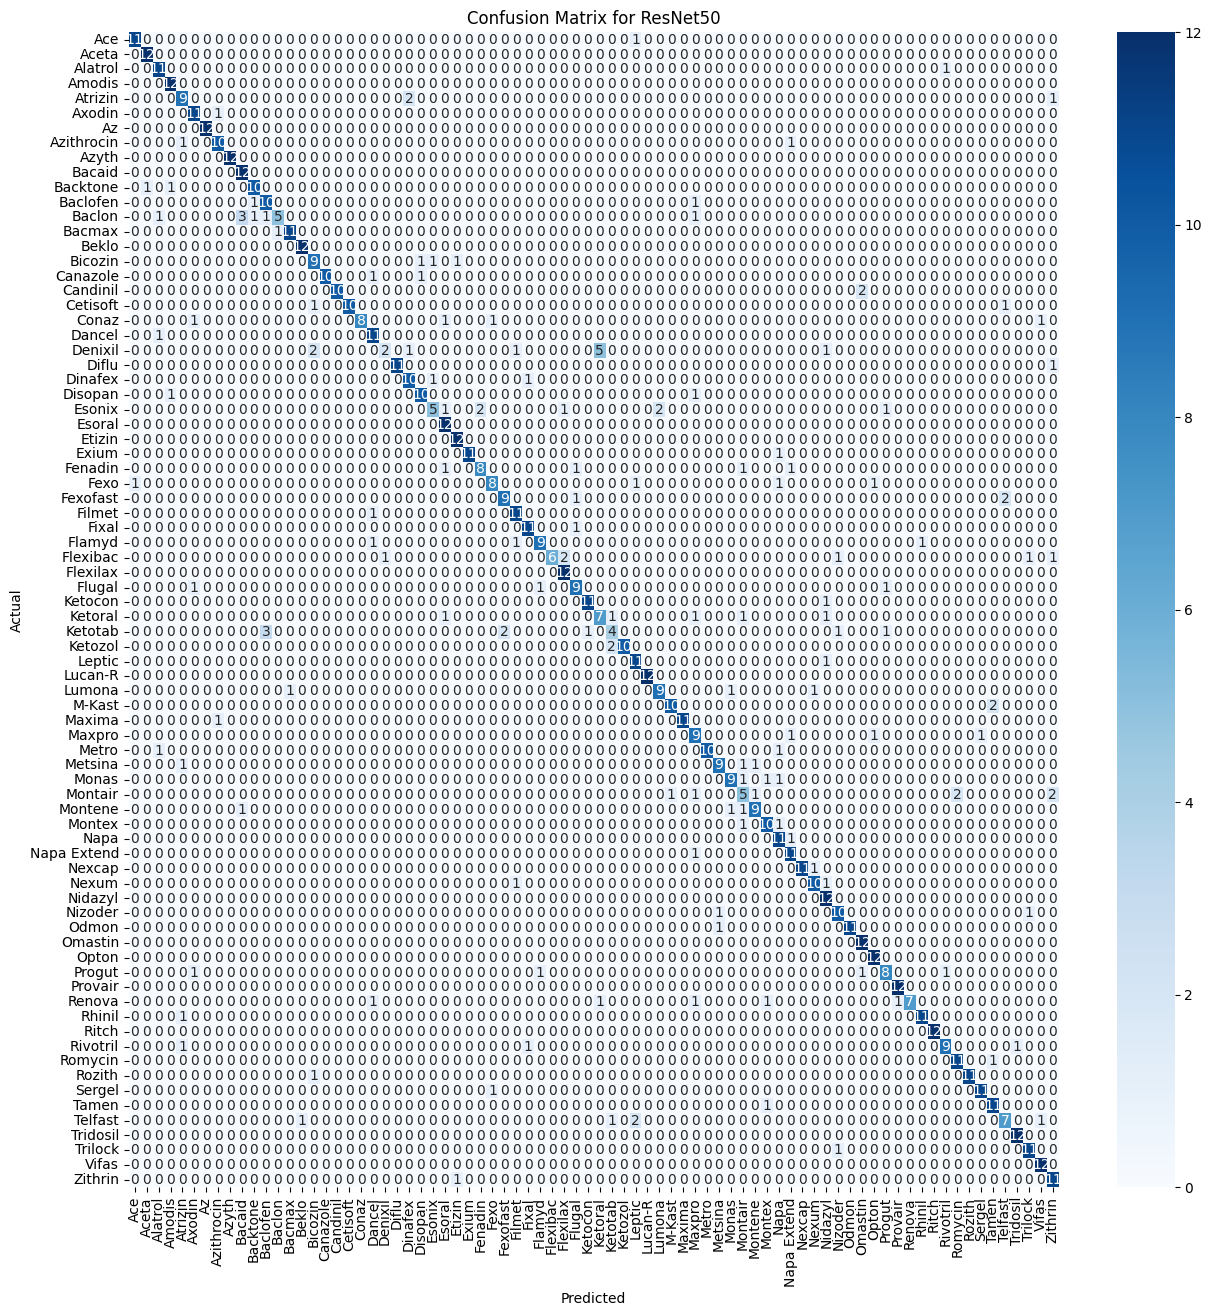

--------------------------------------------------



--- Evaluating and Benchmarking: DENSENET121 ---


Testing DenseNet121:   0%|          | 0/30 [00:00<?, ?it/s]

--- Finished: DENSENET121 ---
Test Accuracy            : 0.7468
F1 (Macro)               : 0.7400
AUC                      : 0.9842
Kappa                    : 0.7435
Params (M)               : 7.0338
GFLOPs                   : 2.8646
Inference Time (ms/CPU)  : 85.6163
Peak Memory (MB)         : 56.0996


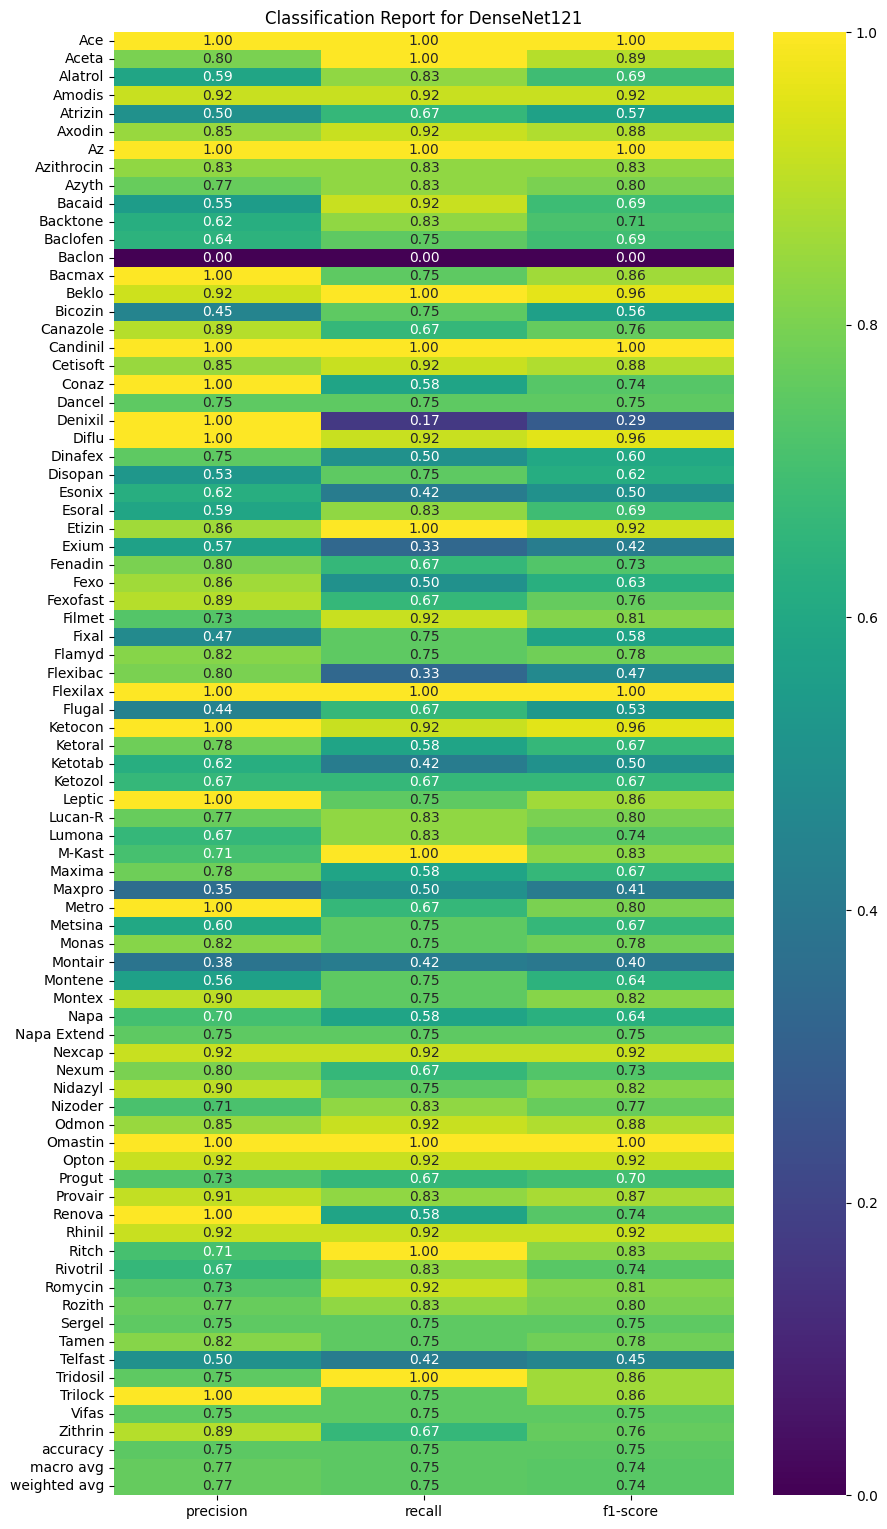

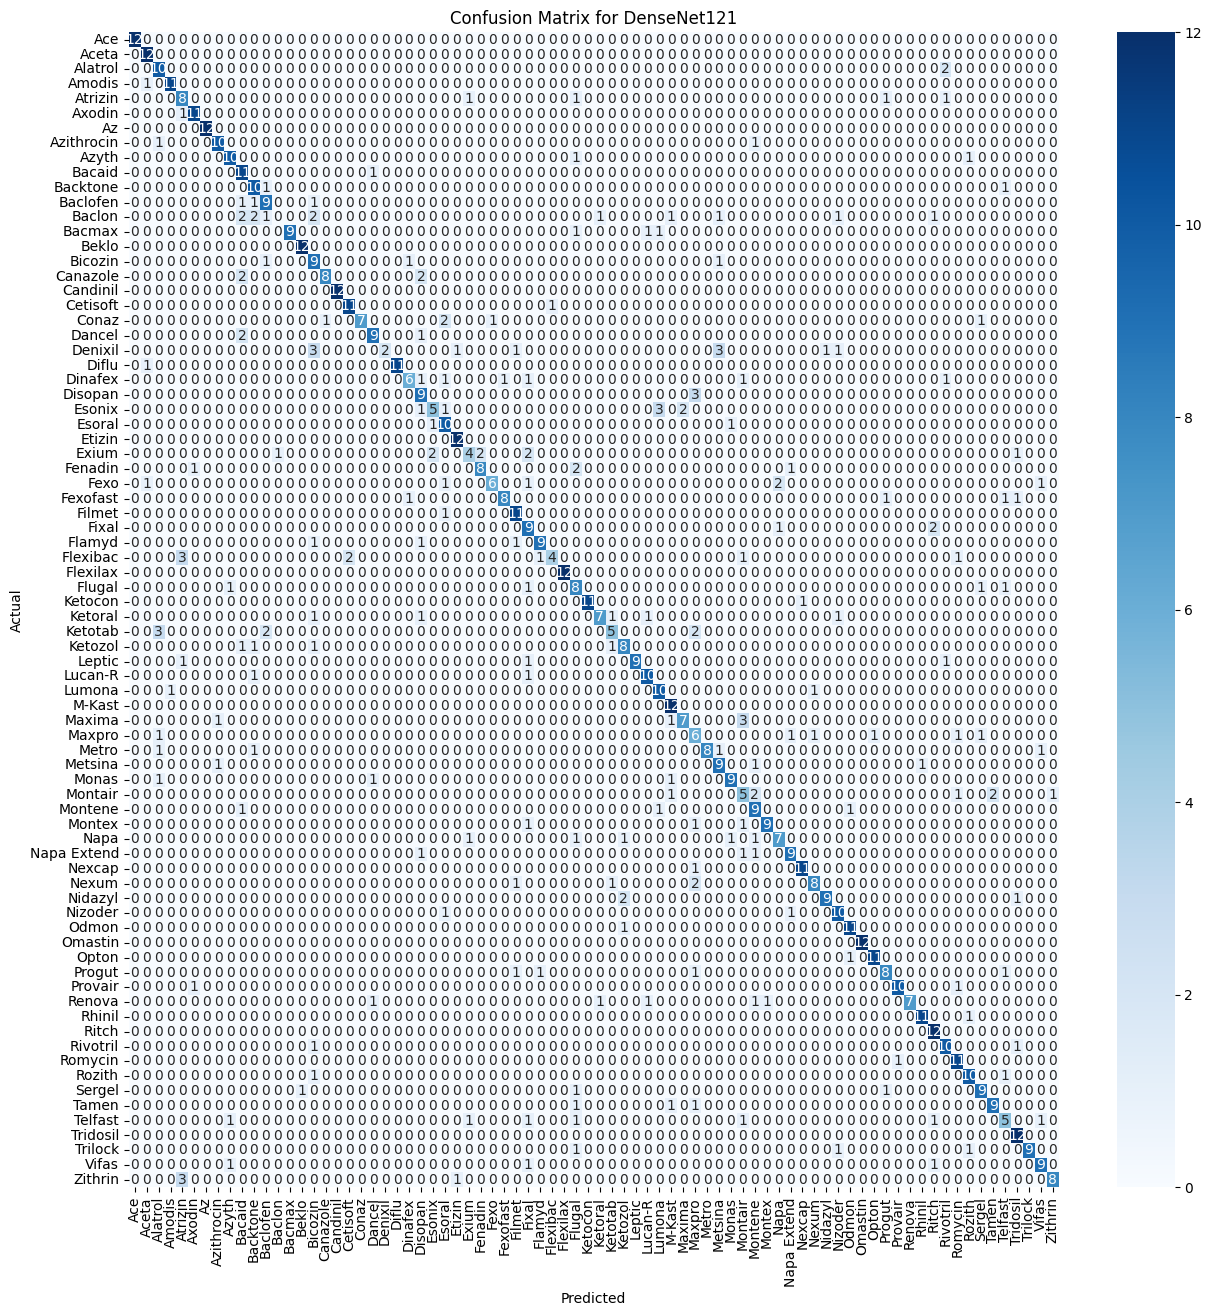

--------------------------------------------------



--- Evaluating and Benchmarking: EFFICIENTNET-V2-S ---


Testing EfficientNet-V2-S:   0%|          | 0/30 [00:00<?, ?it/s]

--- Finished: EFFICIENTNET-V2-S ---
Test Accuracy            : 0.1795
F1 (Macro)               : 0.1833
AUC                      : 0.8532
Kappa                    : 0.1688
Params (M)               : 20.2774
GFLOPs                   : 2.8764
Inference Time (ms/CPU)  : 95.1979
Peak Memory (MB)         : 103.9019


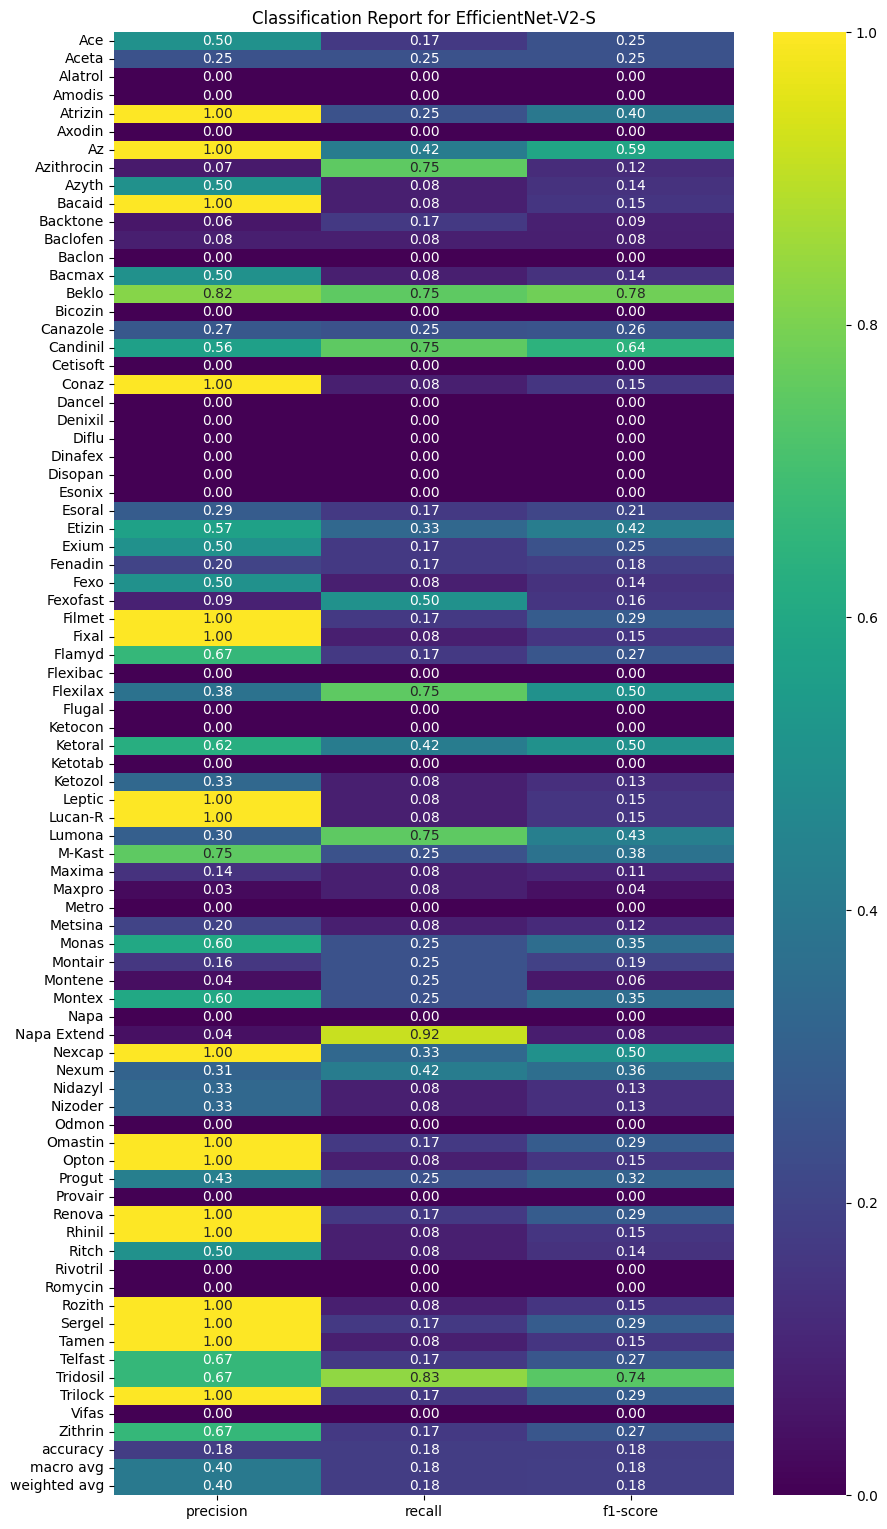

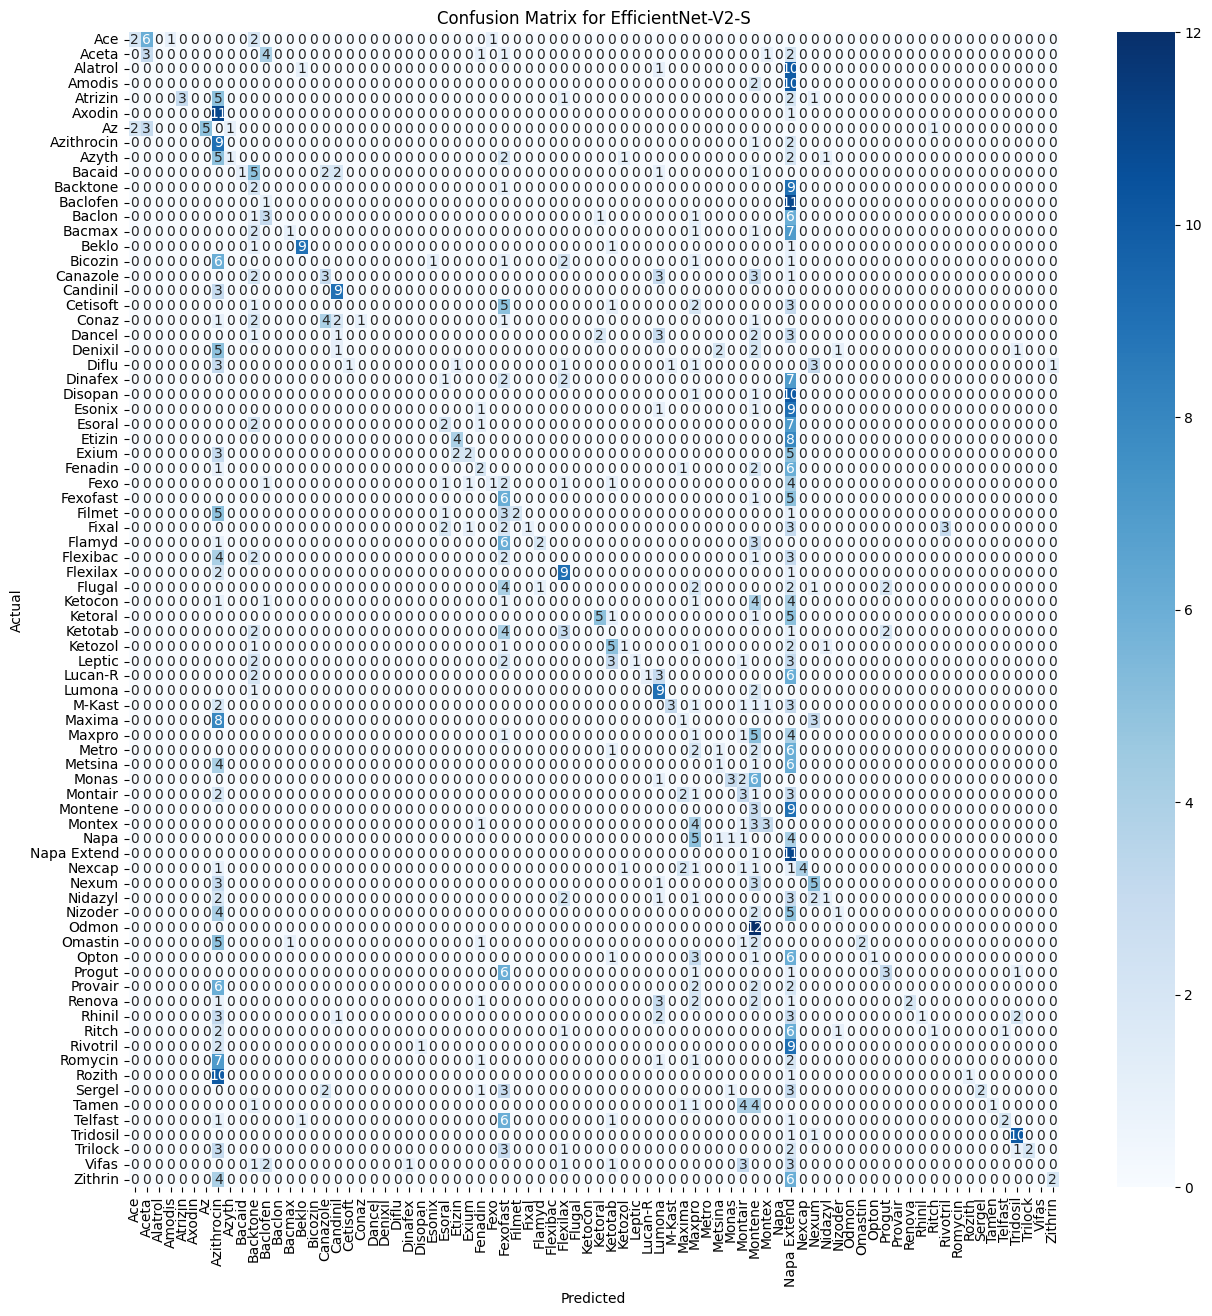

--------------------------------------------------



--- Evaluating and Benchmarking: VIT-B/16 ---


Testing ViT-B/16:   0%|          | 0/30 [00:00<?, ?it/s]

--- Finished: VIT-B/16 ---
Test Accuracy            : 0.7585
F1 (Macro)               : 0.7505
AUC                      : 0.9853
Kappa                    : 0.7554
Params (M)               : 85.8586
GFLOPs                   : 16.8667
Inference Time (ms/CPU)  : 198.7256
Peak Memory (MB)         : 354.8071


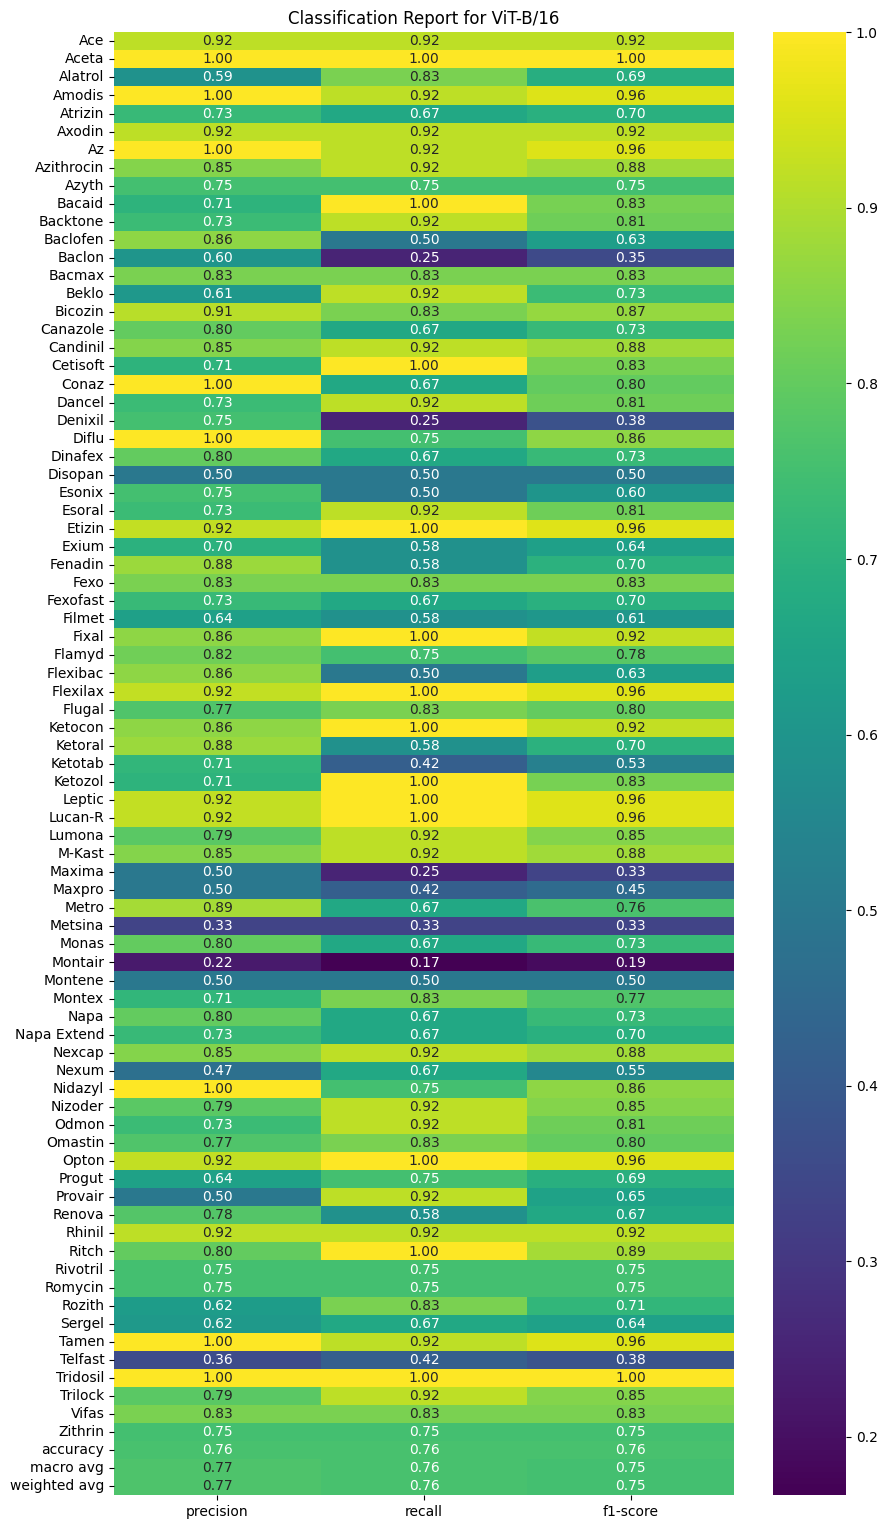

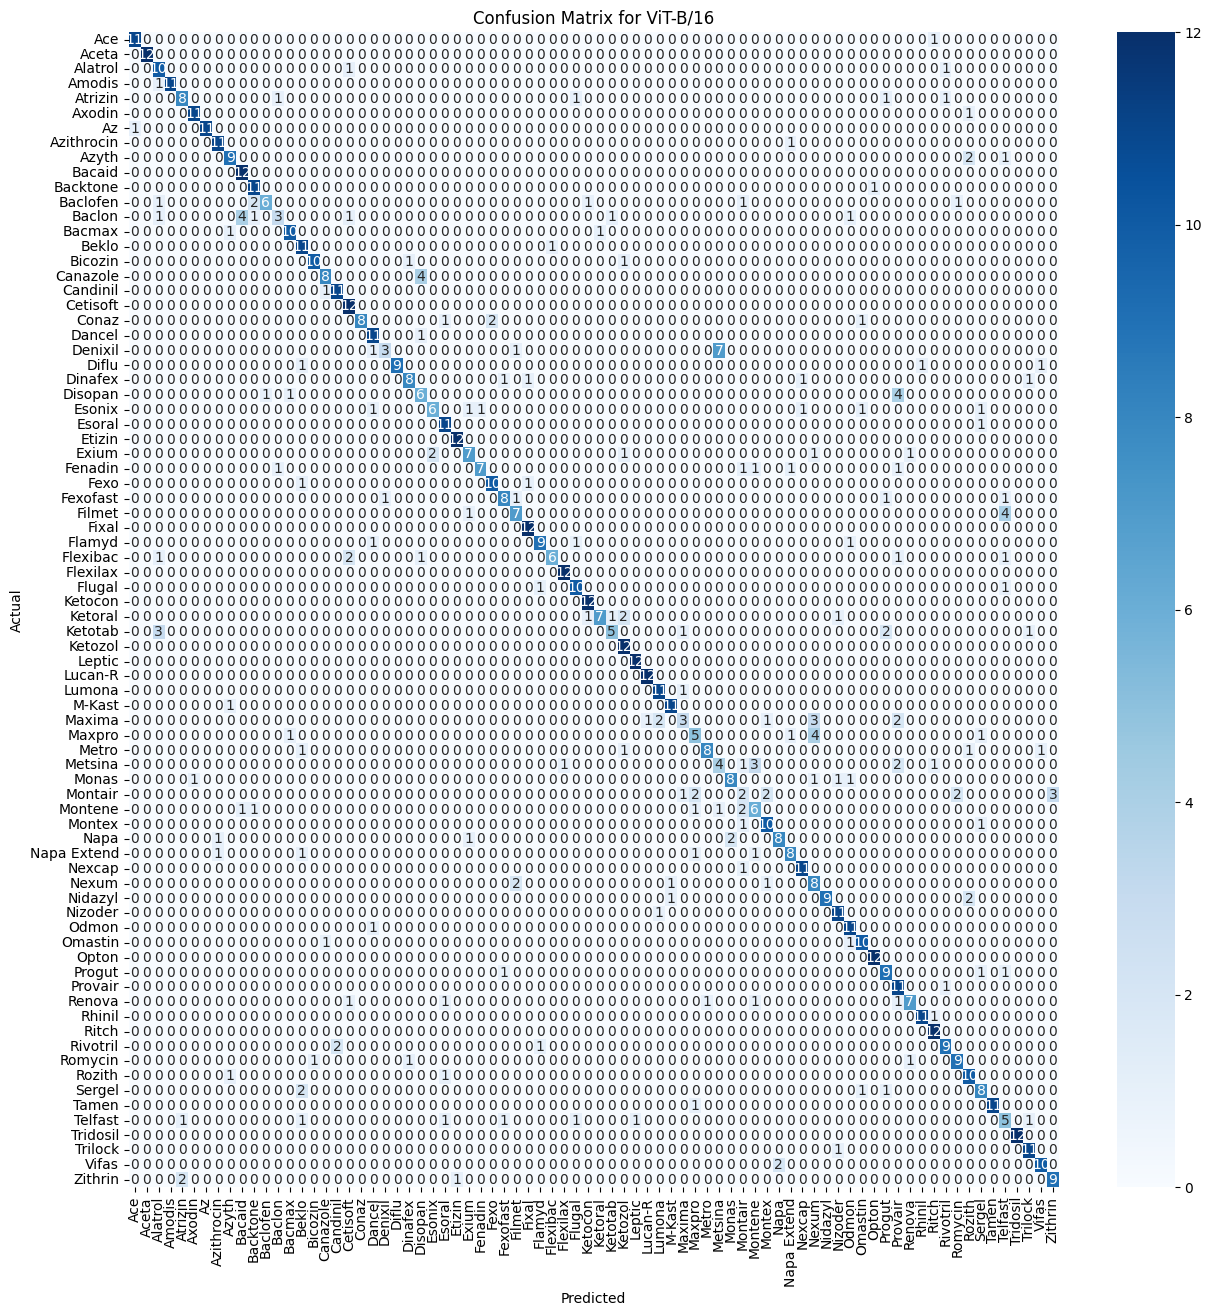

--------------------------------------------------



--- Evaluating and Benchmarking: SWIN-T ---


Testing Swin-T:   0%|          | 0/30 [00:00<?, ?it/s]

--- Finished: SWIN-T ---
Test Accuracy            : 0.8280
F1 (Macro)               : 0.8228
AUC                      : 0.9912
Kappa                    : 0.8258
Params (M)               : 27.5793
GFLOPs                   : 4.5085
Inference Time (ms/CPU)  : 93.7843
Peak Memory (MB)         : 141.4160


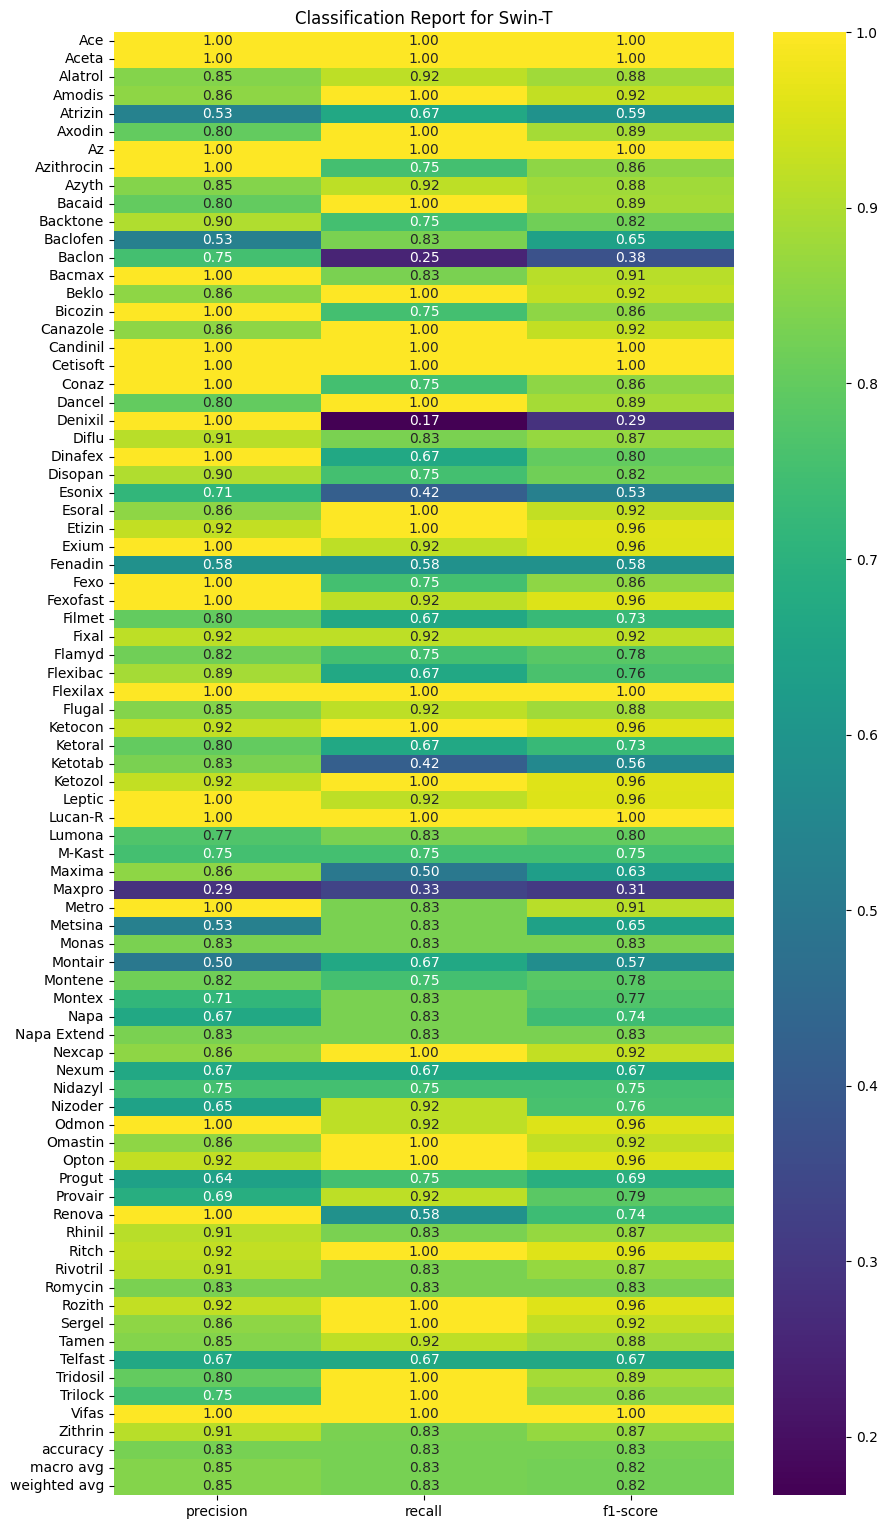

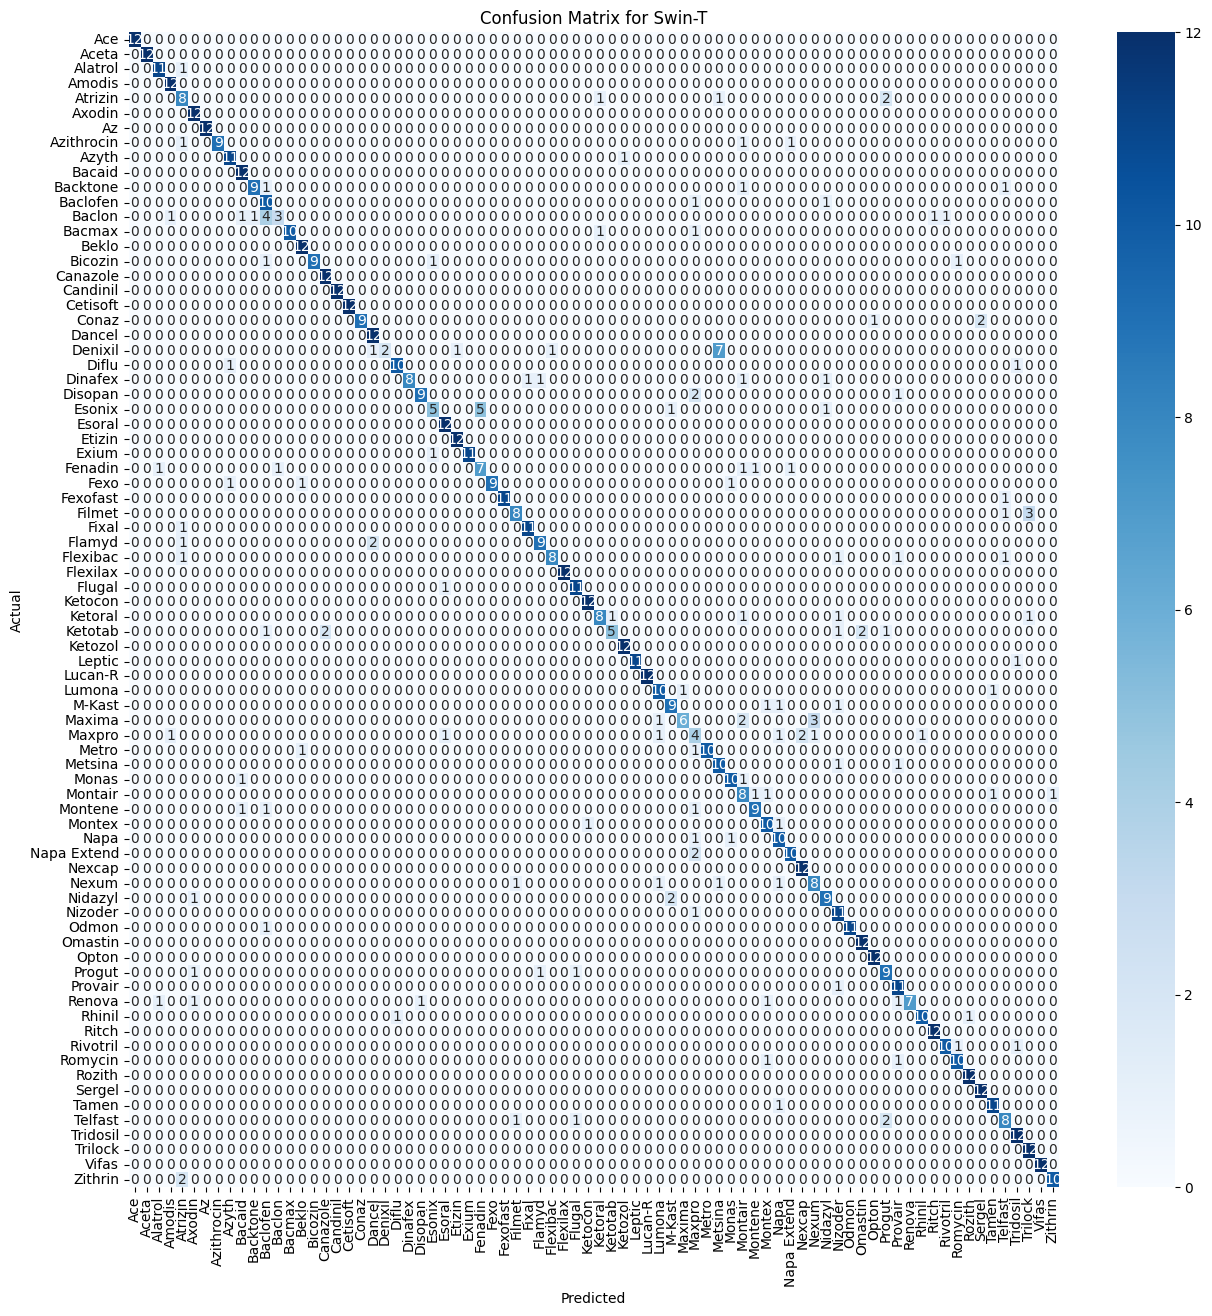

--------------------------------------------------



--- Evaluating and Benchmarking: MAXVIT-T ---


Testing MaxViT-T:   0%|          | 0/30 [00:00<?, ?it/s]

--- Finished: MAXVIT-T ---
Test Accuracy            : 0.8130
F1 (Macro)               : 0.8050
AUC                      : 0.9902
Kappa                    : 0.8106
Params (M)               : 30.4476
GFLOPs                   : 5.6077
Inference Time (ms/CPU)  : 157.8945
Peak Memory (MB)         : 168.6333


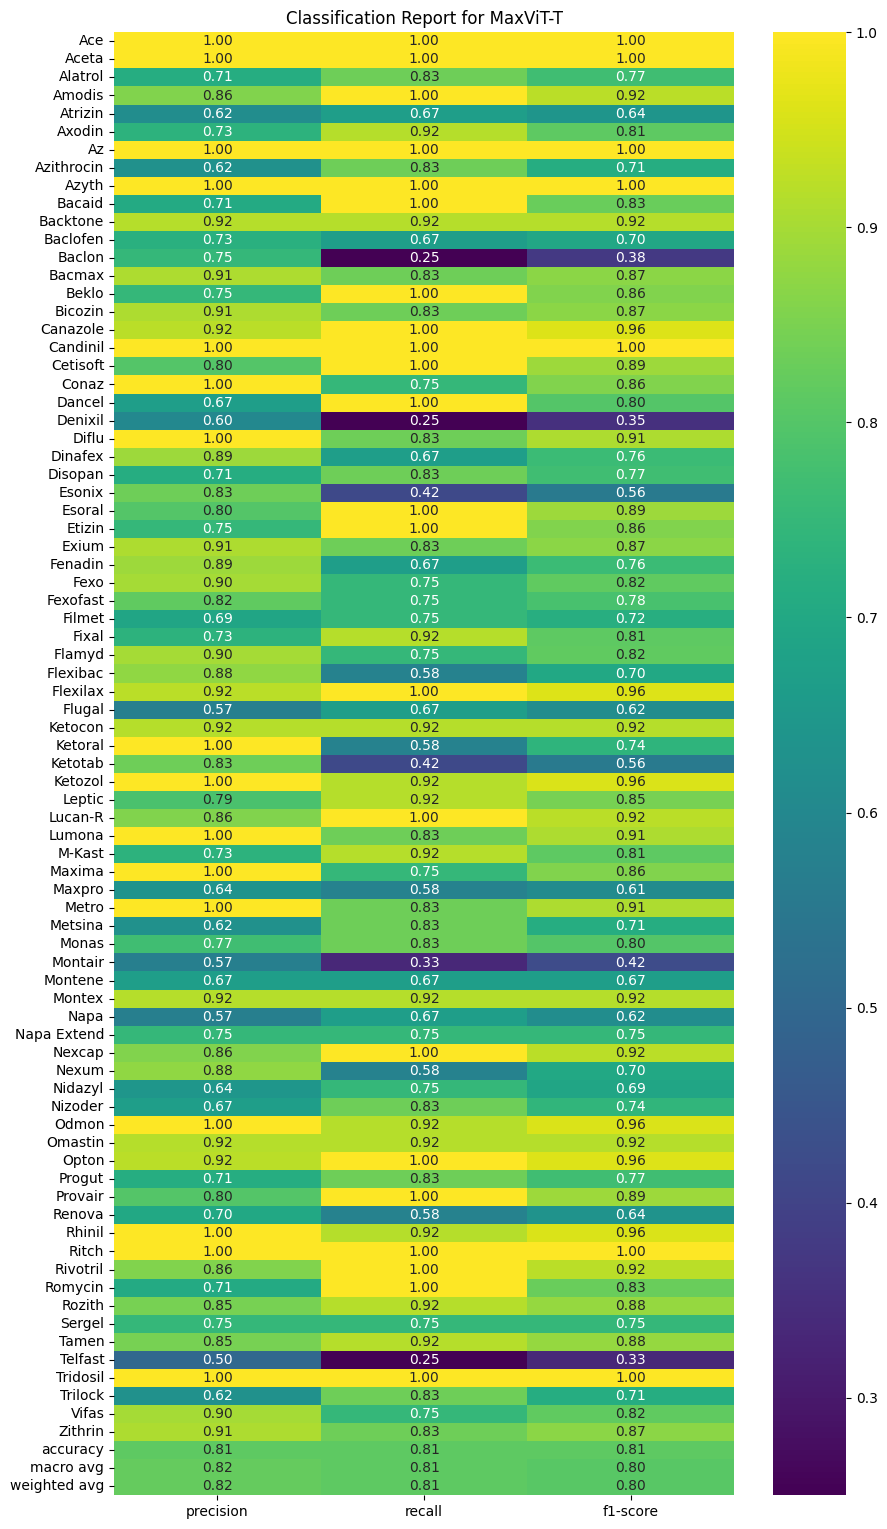

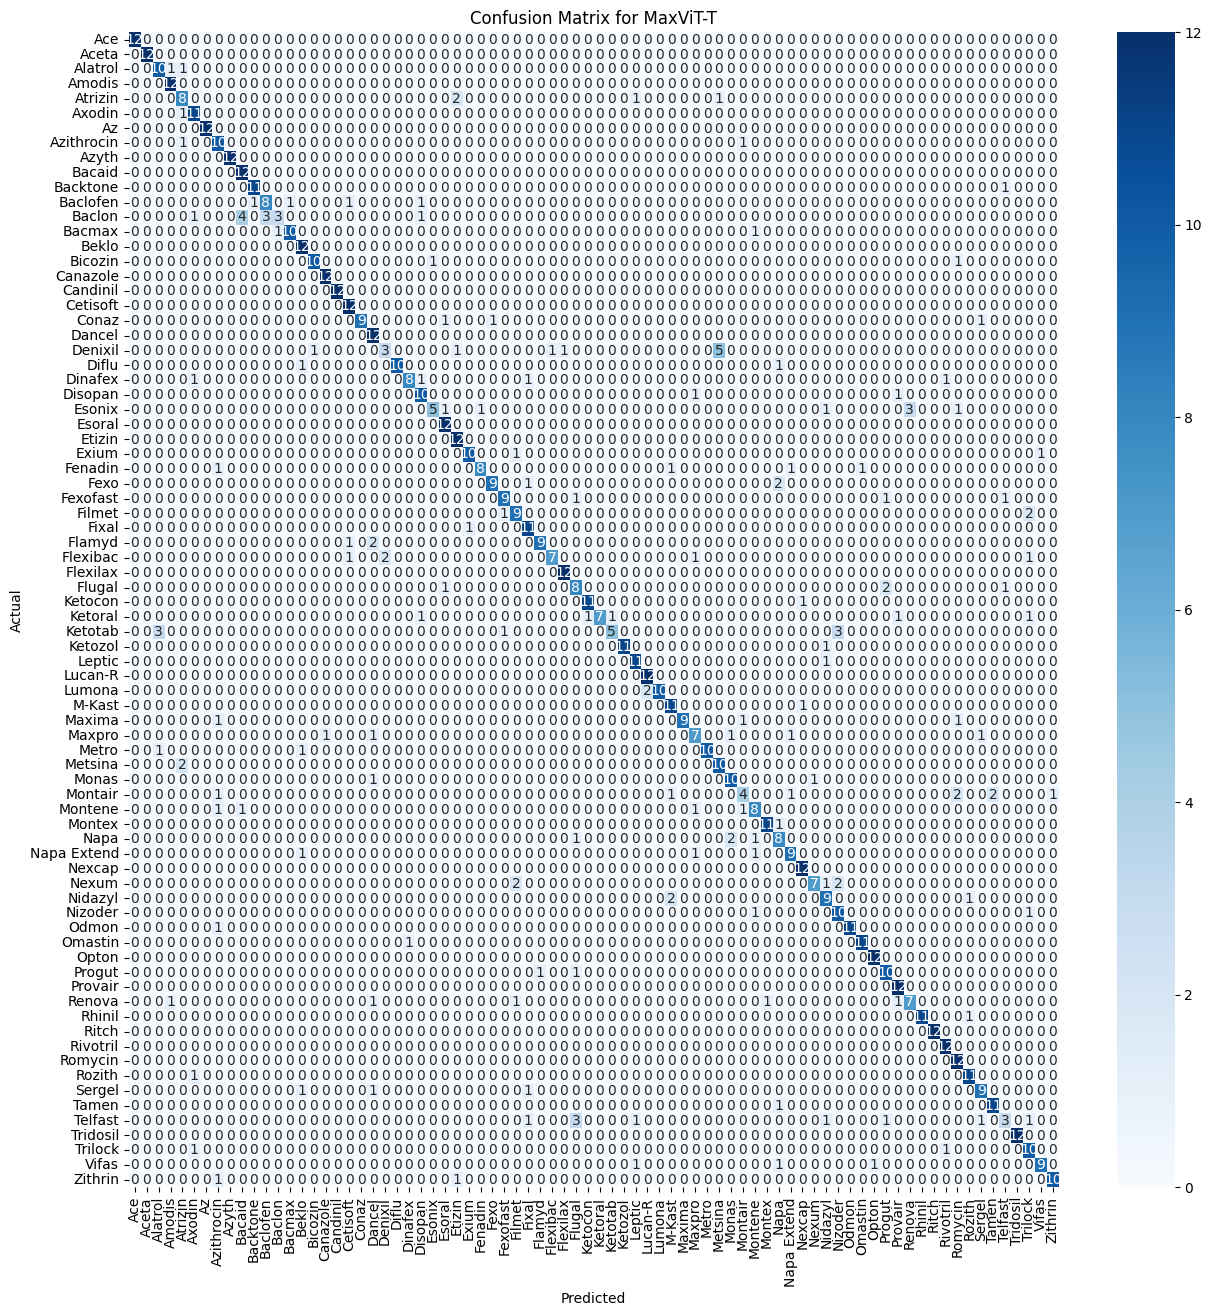

--------------------------------------------------



--- Evaluating and Benchmarking: CONVNEXT-TINY ---


Testing ConvNeXt-Tiny:   0%|          | 0/30 [00:00<?, ?it/s]

--- Finished: CONVNEXT-TINY ---
Test Accuracy            : 0.8387
F1 (Macro)               : 0.8333
AUC                      : 0.9930
Kappa                    : 0.8366
Params (M)               : 27.8801
GFLOPs                   : 4.4697
Inference Time (ms/CPU)  : 67.6237
Peak Memory (MB)         : 138.0166


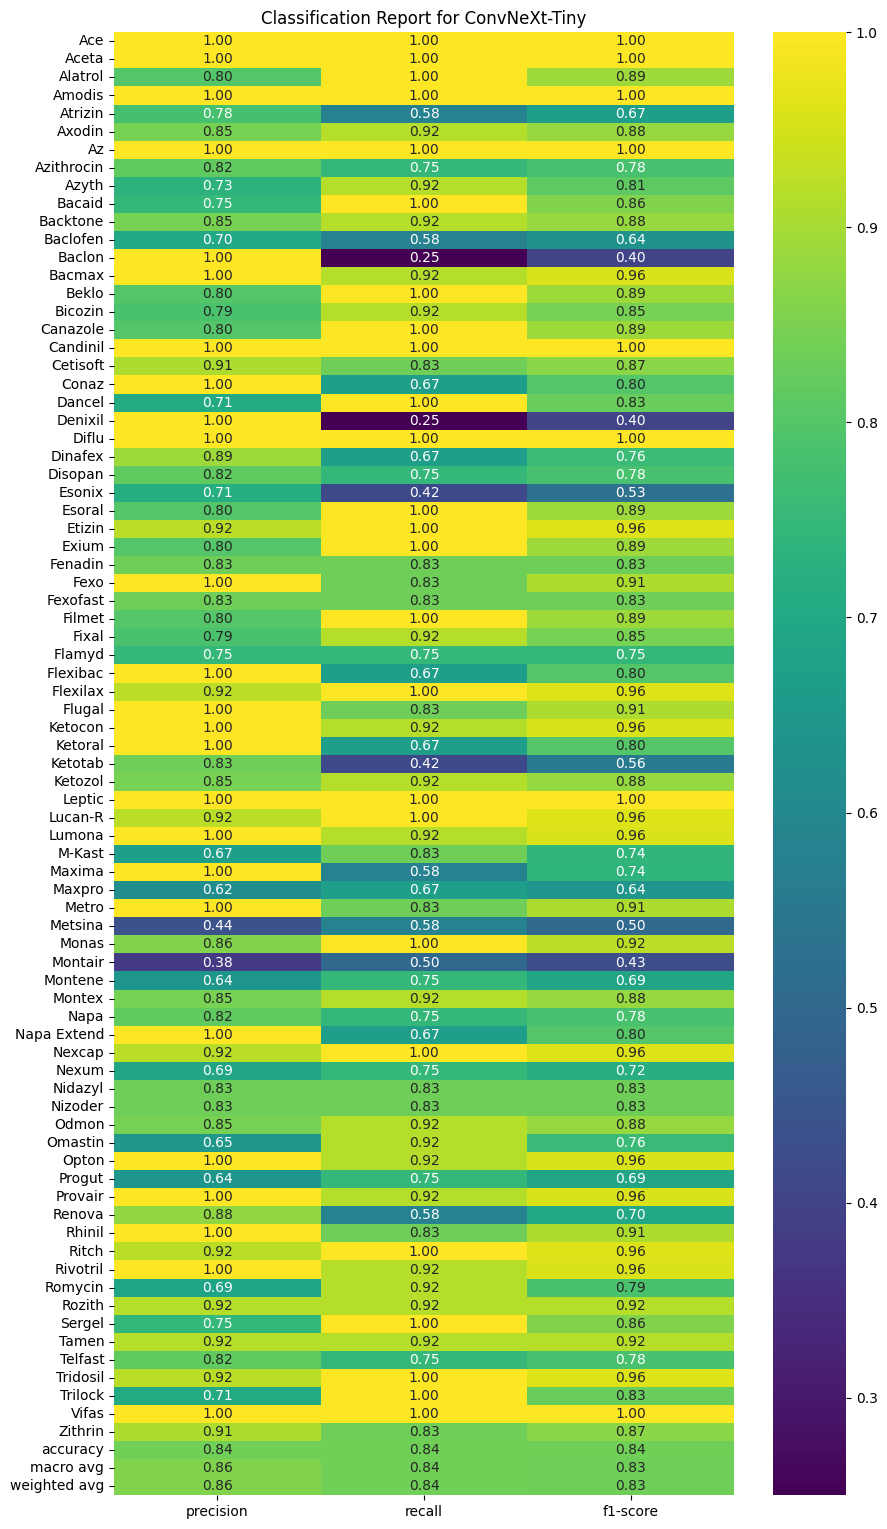

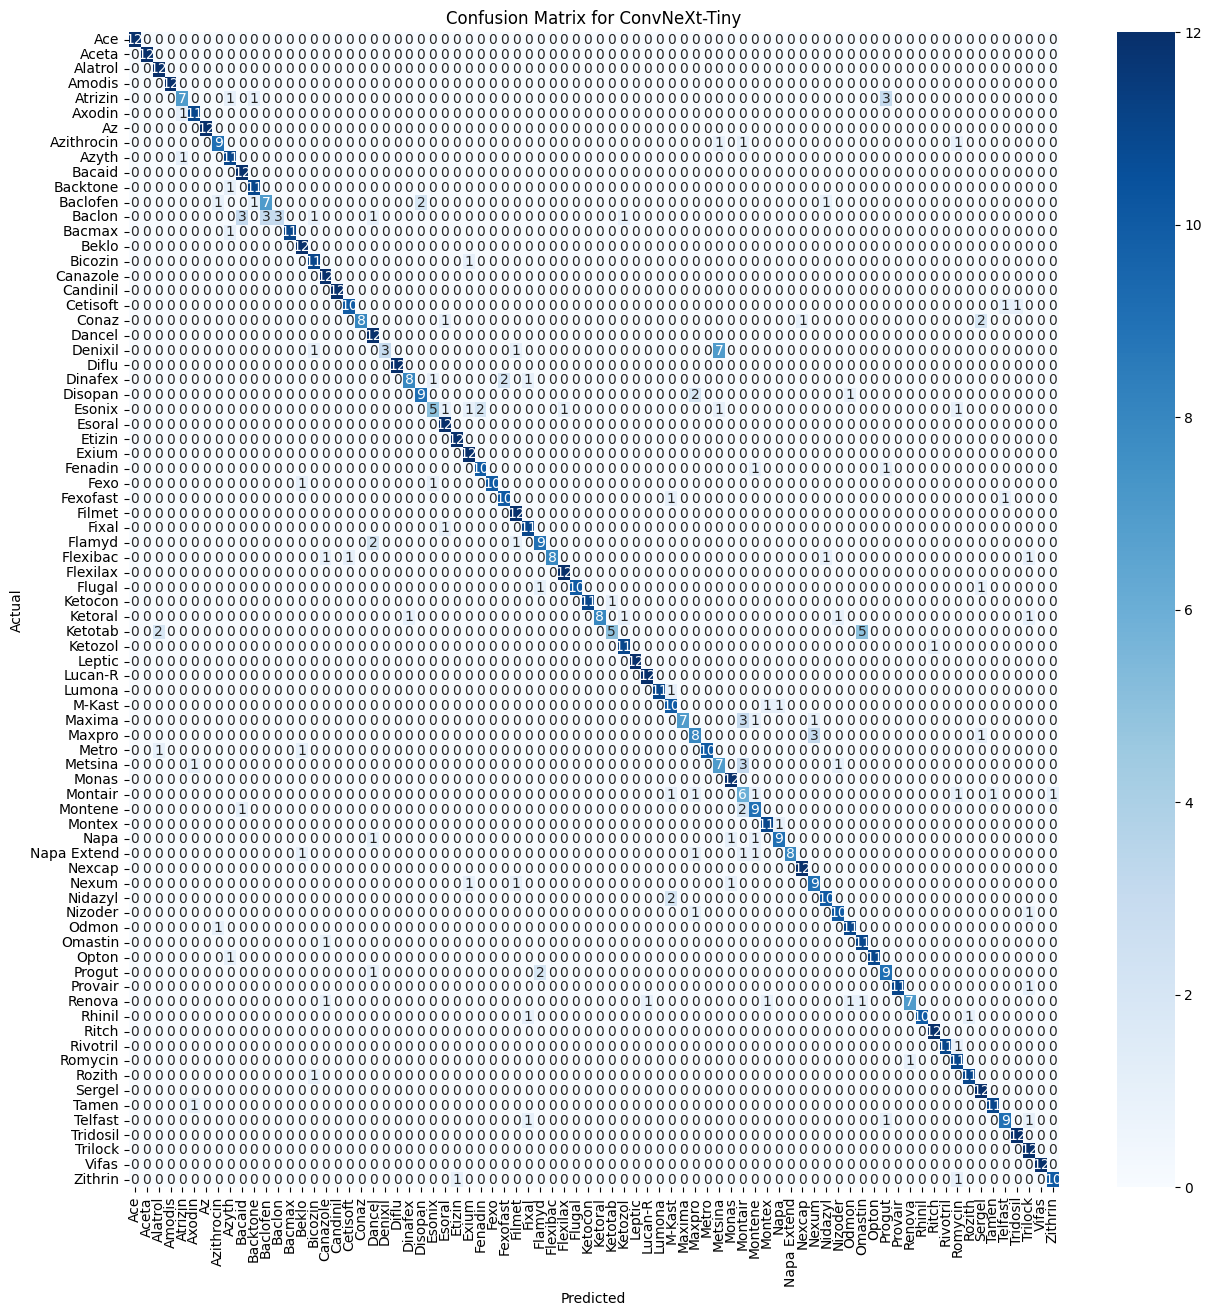

--------------------------------------------------



--- Evaluating and Benchmarking: MOBILENET-V3-LARGE ---


Testing MobileNet-V3-Large:   0%|          | 0/30 [00:00<?, ?it/s]

--- Finished: MOBILENET-V3-LARGE ---
Test Accuracy            : 0.8301
F1 (Macro)               : 0.8231
AUC                      : 0.9901
Kappa                    : 0.8279
Params (M)               : 4.3019
GFLOPs                   : 0.2249
Inference Time (ms/CPU)  : 21.8658
Peak Memory (MB)         : 41.9385


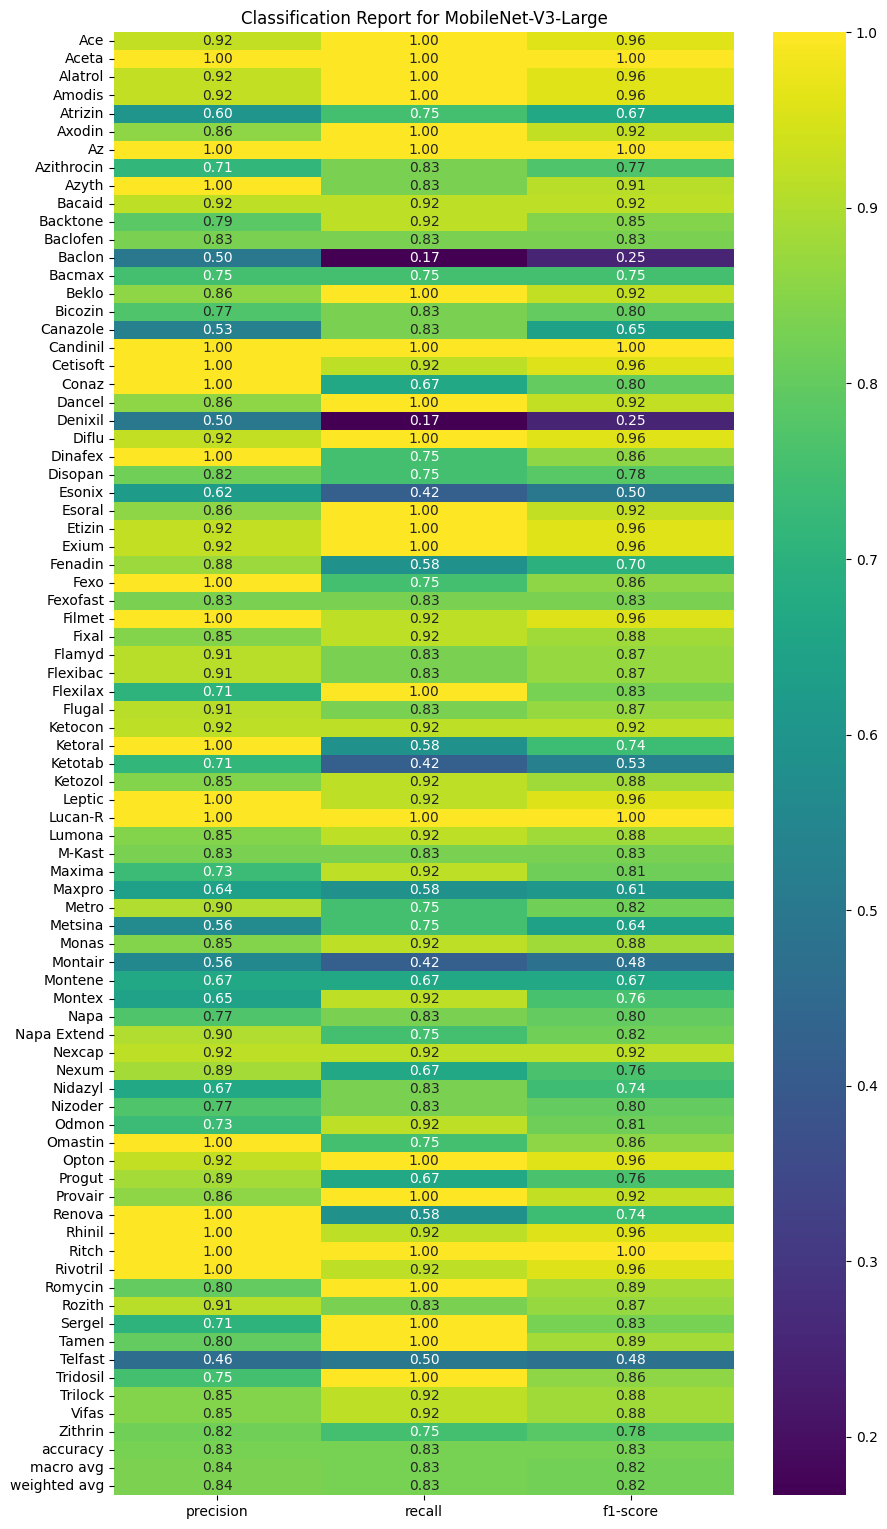

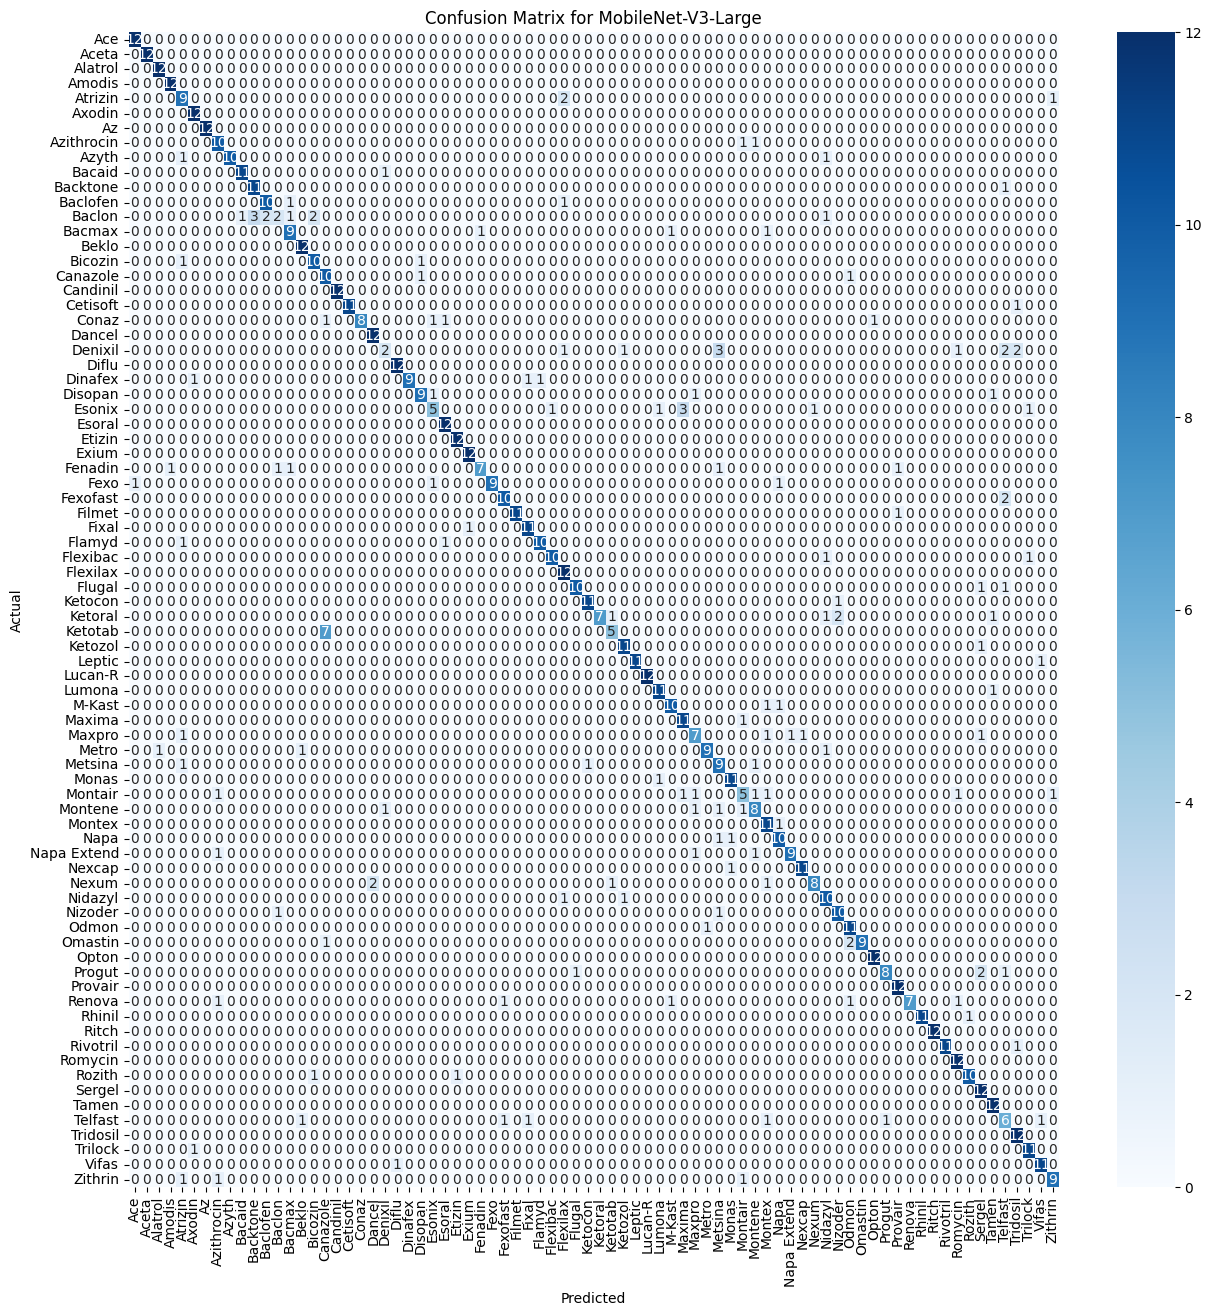

--------------------------------------------------



--- Evaluating and Benchmarking: REGNET-Y-16GF ---


Testing RegNet-Y-16GF:   0%|          | 0/30 [00:00<?, ?it/s]

--- Finished: REGNET-Y-16GF ---
Test Accuracy            : 0.8237
F1 (Macro)               : 0.8178
AUC                      : 0.9869
Kappa                    : 0.8214
Params (M)               : 80.8011
GFLOPs                   : 15.9605
Inference Time (ms/CPU)  : 252.6845
Peak Memory (MB)         : 355.3584


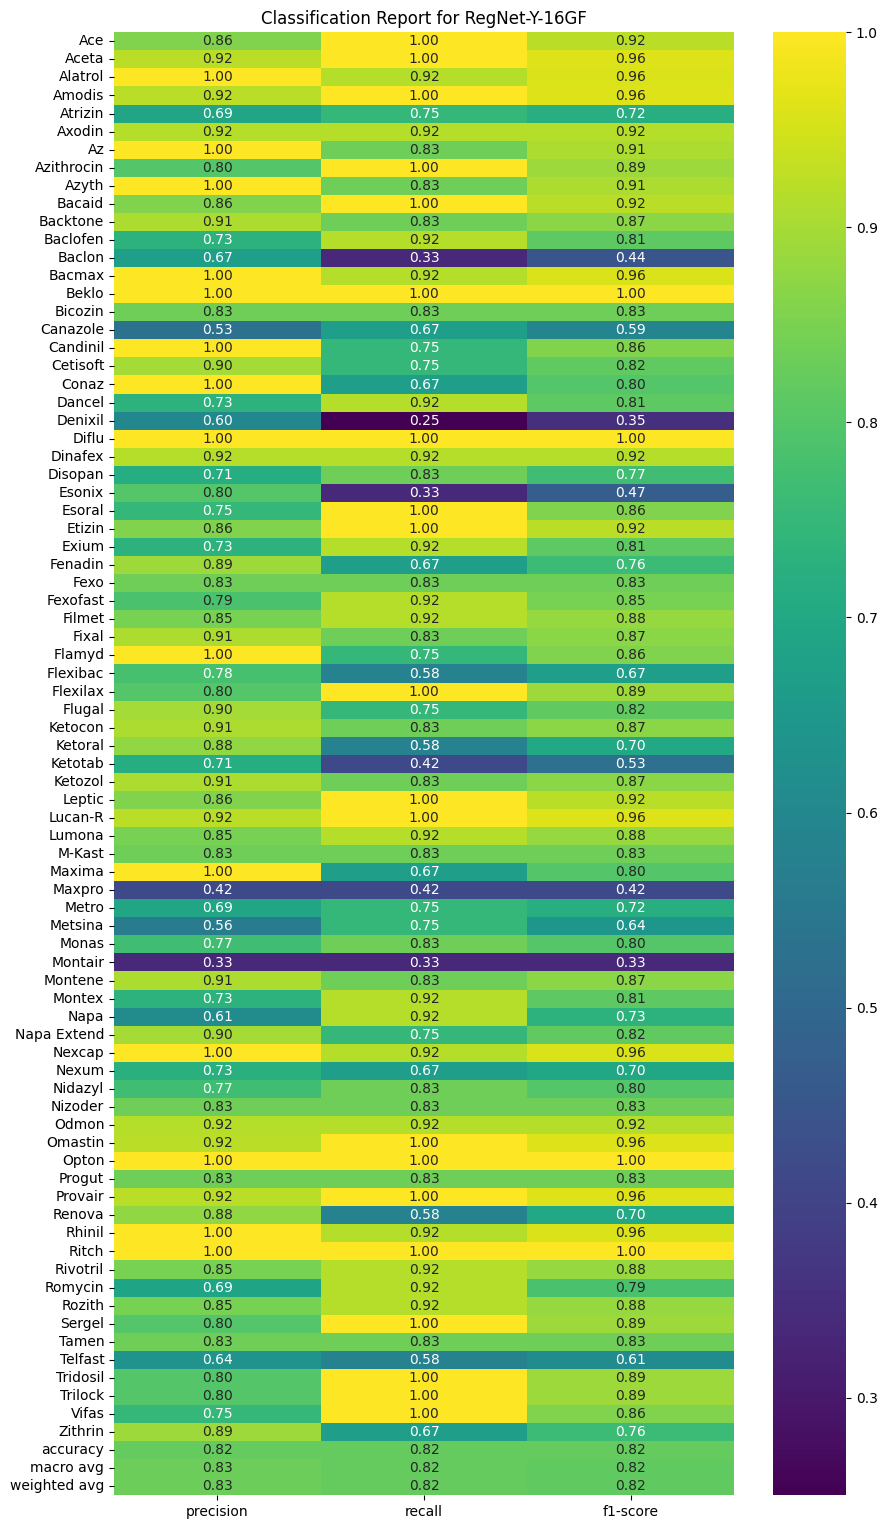

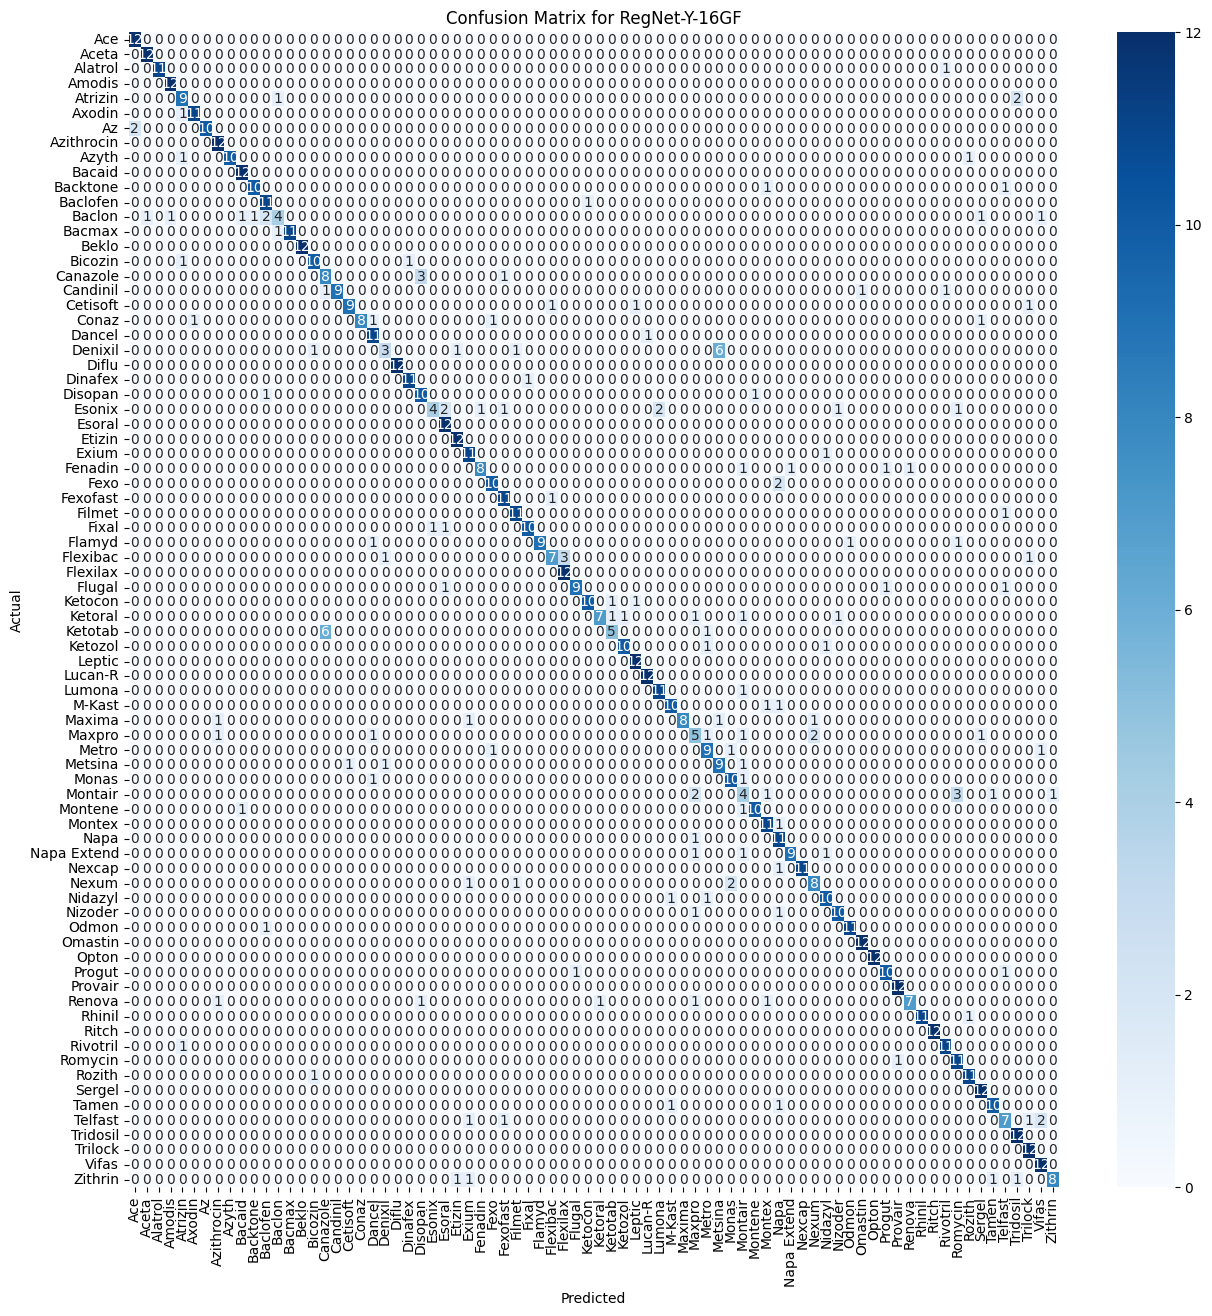

--------------------------------------------------


🎉 All models have been evaluated! 🎉


In [84]:
model_creators = get_model_architectures(num_classes)
model_iterator = tqdm(model_creators.items(), desc="Evaluating All Models")

for model_name, create_model_fn in model_iterator:
    model_iterator.set_postfix_str(f"Currently: {model_name}")

    try:
        model = create_model_fn()
        safe_model_name = model_name.lower().replace('/', '_').replace('-', '_')
        model_path = os.path.join(CONFIG["base_model_path"], f'{safe_model_name}_finetuned_best_model.pth')

        if not os.path.exists(model_path):
            print(f"Warning: Weight file not found for {model_name} at {model_path}. Skipping.")
            continue

        model.load_state_dict(torch.load(model_path, map_location=CONFIG["device"]))

        FINAL_RESULTS_TABLE[model_name] = evaluate_and_benchmark(
            model,
            model_name,
            CONFIG["image_size"],
            dataloaders['test'],
            class_names,
            CONFIG["device"]
        )
    except Exception as e:
        print(f"An error occurred while evaluating {model_name}: {e}")

print("\n🎉 All models have been evaluated! 🎉")

---

# Final Report



--- FINAL COMPARISON TABLE (Sorted by Practicality Score) ---


,Test Accuracy,F1 (Macro),AUC,Kappa,Params (M),GFLOPs,Inference Time (ms/CPU),Peak Memory (MB),Practicality Score
MobileNet-V3-Large,0.8301,0.8231,0.9901,0.8279,4.3019,0.2249,21.8658,41.9385,9.9013
ConvNeXt-Tiny,0.8387,0.8333,0.9930,0.8366,27.8801,4.4697,67.6237,138.0166,8.9039
ResNet50,0.8291,0.8228,0.9910,0.8268,23.6679,4.1096,75.5014,136.8926,8.7775
DenseNet121,0.7468,0.7400,0.9842,0.7435,7.0338,2.8646,85.6163,56.0996,8.7310
Swin-T,0.8280,0.8228,0.9912,0.8258,27.5793,4.5085,93.7843,141.4160,8.5490
MaxViT-T,0.8130,0.8050,0.9902,0.8106,30.4476,5.6077,157.8945,168.6333,7.6286
ViT-B/16,0.7585,0.7505,0.9853,0.7554,85.8586,16.8667,198.7256,354.8071,5.8680
VGG16,0.8504,0.8425,0.9904,0.8485,27.6003,15.3595,182.1680,482.6436,5.7611
RegNet-Y-16GF,0.8237,0.8178,0.9869,0.8214,80.8011,15.9605,252.6845,355.3584,5.5898
EfficientNet-V2-S,0.1795,0.1833,0.8532,0.1688,20.2774,2.8764,95.1979,103.9019,5.5456


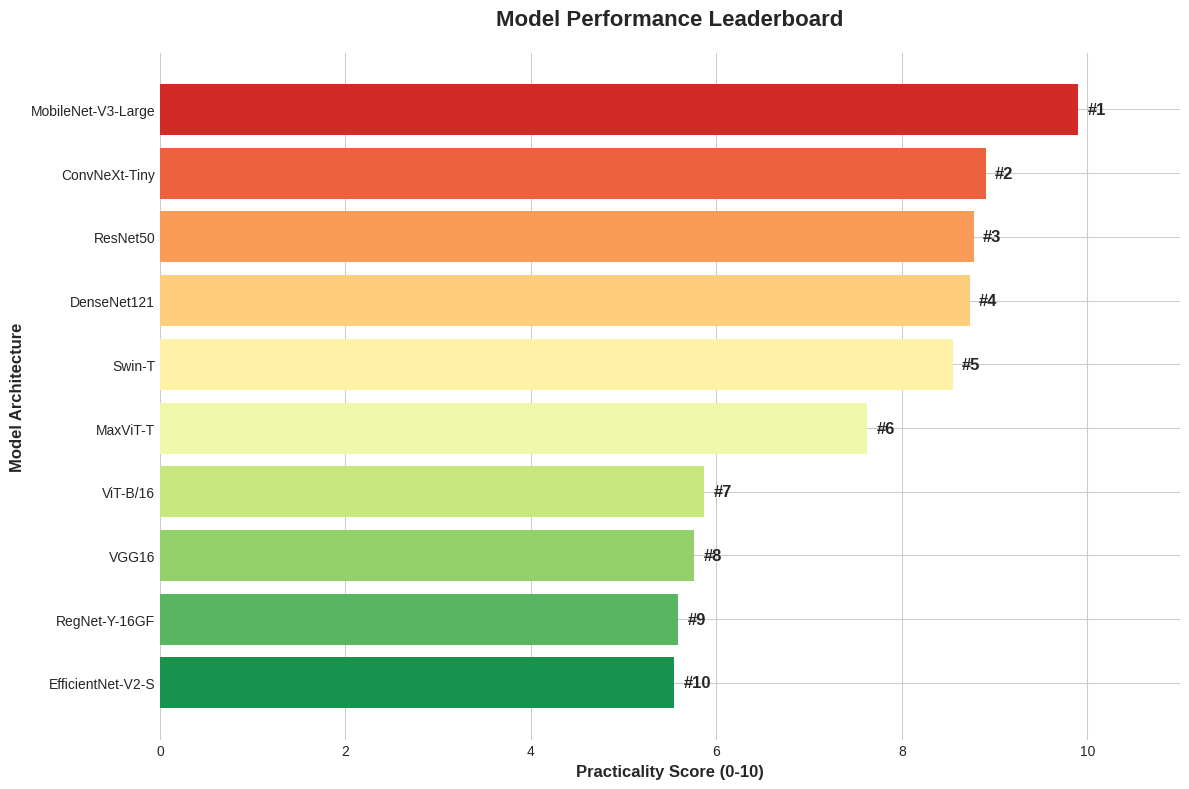

In [95]:
generate_final_report(FINAL_RESULTS_TABLE)